<div style="position: relative; background: linear-gradient(135deg, #24398A 0%, #1a2a66 100%); border-radius: 20px 20px 0px 0px; padding: 30px; box-shadow: 0 8px 16px rgba(36, 57, 138, 0.3);">
  
  <!-- Logo UNISON - Derecha -->
  <div style="position: absolute; top: 20px; right: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/logo_unison.jpg" alt="UNISON" style="height: 160px;">
  </div>
  
  <!-- Imagen Izquierda -->
  <div style="position: absolute; top: 20px; left: 20px; background: white; padding: 4px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.2);">
    <img src="images/genetic_banner.jpg" alt="Curso" style="height: 160px;">
  </div>
   
  <!-- Título centrado -->
  <div style="color: white; max-width: 60%; margin: 0 auto; text-align: center;">
    <h1 style="color: #EBA93B; margin: 0; font-size: 28px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
      Metaheurísticas para Ciencia de Datos: <br>Teoría y Práctica
    </h1><br>
    <h3 style="margin: 15px 0 5px 0; font-size: 16px; opacity: 0.95;">Maestría en Ciencia de Datos</br></br>
    Ramón Soto C. / ramon.soto@unison.mx</h3>
  </div>
</div>

<div style="background: white; border: 3px solid #EBA93B; border-radius: 0px 0px 20px 20px; padding: 25px;">
  <div style="display: flex; align-items: center; margin-bottom: 15px;">
    <div style="background: #24398A; color: white; font-size: 24px; font-weight: bold; padding: 10px 20px; border-radius: 8px; margin-right: 20px;">03</div>
    <div>
      <h2 style="color: #24398A; margin: 0;">Computación Evolutiva: Algoritmos basados en la evolución</h2>
      <p style="color: #666; margin: 5px 0 0 0; font-style: italic;">De 3.800 millones de años de evolución a metaheurísticas poblacionales</p>
    </div>
  </div>
  
<div style="background: #f8f9fa; padding: 15px; border-radius: 5px; border-left: 4px solid #24398A;">
    <h4 style="color: #24398A; margin-top: 0;"><strong>Presentación general</strong></h4>
    <p style="line-height: 1.7; color: #333;">
    La evolución biológica es el algoritmo de optimización más exitoso de la naturaleza: durante 3.800 millones de años ha resuelto problemas de diseño, adaptación y supervivencia en ambientes hostiles, inciertos y cambiantes. La pregunta natural desde ML es: ¿Podemos abstraer sus principios fundamentales—variación, selección, herencia—y convertirlos en métodos computacionales? 
    </p>
    <p style="line-height: 1.7; color: #333;">
    Esta lección explora los <strong>algoritmos evolutivos</strong>, una familia de metaheurísticas donde poblaciones de soluciones candidatas compiten, se recombinan y mutan para adaptarse progresivamente a un paisaje de <em>fitness</em>. Desde los algoritmos genéticos clásicos hasta las estrategias evolutivas modernas, veremos cómo la metáfora de la selección natural se traduce en mecanismos computacionales robustos capaces de navegar espacios de búsqueda rugosos, discontinuos y multimodales—exactamente los problemas que encontramos en sistemas complejos.
    </p>
    <p style="line-height: 1.7; color: #333;">
    Analizaremos también los desafíos inherentes: convergencia prematura hacia óptimos locales, crecimiento descontrolado de la complejidad (<em>bloat</em>), balance entre exploración y explotación. Y aprenderemos estrategias para superarlos, preparando el camino para aplicaciones en calibración de modelos, selección de características, y optimización de hiperparámetros en ciencia de datos.
    </p>
  </div>
</div>


<div style="padding: 15px 20px; background-color: #f8f9fa; margin: 20px 0;">
    <p style="font-size: 16px; line-height: 1.8; color: #2c3e50; margin: 0 0 15px 0;">
        En la lección anterior vimos que los sistemas complejos—desde el atractor de Lorenz hasta mercados financieros—violan sistemáticamente los supuestos de los métodos clásicos. No son lineales, no son convexos, no son estacionarios. En esos paisajes rugosos y multimodales, <strong>necesitamos métodos que no asuman estructura favorable</strong>.
    </p>
    <p style="font-size: 16px; line-height: 1.8; color: #2c3e50; margin: 0;">
        Los <strong>algoritmos evolutivos</strong> son precisamente eso: métodos de búsqueda poblacional inspirados en la selección natural, que exploran el espacio de soluciones de manera distribuida y paralela. Implementan procesos de <em>variación</em> (mutación, recombinación), <em>selección</em> (supervivencia diferencial), y <em>herencia</em> (transmisión de características exitosas), permitiendo que poblaciones de candidatos evolucionen hacia regiones de alta aptitud sin quedarse atrapados en óptimos locales. Esta lección explora cómo convertir la metáfora evolutiva en algoritmos rigurosos y aplicables.
    </p>
</div>


In [1]:
# CONFIGURACIÓN INICIAL
# =====================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
from scipy import stats
from itertools import combinations
import math
from mpl_toolkits.mplot3d import Axes3D

# Configuración estética
np.set_printoptions(precision=4, suppress=True)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12


# Reproducibilidad
np.random.seed(42)

print("Librerías cargadas exitosamente.\n")

Librerías cargadas exitosamente.



## 1. La evolución como algoritmo

En las lecciones anteriores discutimos que gran parte de la ciencia avanza gracias a **metáforas**: imágenes conceptuales que permiten pensar lo que aún no puede formularse con precisión matemática. 

La evolución biológica no es una excepción. Es un proceso natural que, visto con distancia, se comporta como un **algoritmo distribuido**, lento pero obstinadamente eficaz, que explora un espacio inmenso de posibilidades.

En **Computación Evolutiva (CE)**, igual que en cualquier otro método metaheurístico, no tratamos de "copiar" ese proceso, sino de extraer su **estructura funcional**:

```
DIVERSIDAD → SELECCIÓN → VARIACIÓN → SUPERVIVENCIA DIFERENCIAL
```

Desde esta perspectiva, los algoritmos evolutivos son **metáforas computacionales de la adaptación**, un puente directo entre naturaleza y diseño algorítmico. Esta estructura —muy simple en apariencia— permite resolver problemas donde los métodos convencionales fallan:

- Optimización no convexa
- Espacios ruidosos y discontinuos
- Problemas combinatorios (NP-duros)
- Paisajes multimodales

Esta estructura puede describirse en términos de operadores de búsqueda y presión selectiva, lo que permite compararla con métodos deterministas clásicos.

<div style="background: linear-gradient(135deg, #e3f2fd, #bbdefb); border-left: 5px solid #1565c0; padding: 20px; margin: 20px 0; border-radius: 5px;">
<strong>Reflexión epistemológica:</strong> Si aceptamos que las redes neuronales son una metáfora válida (y simplificada) del cerebro, ¿por qué no aceptar que los algoritmos evolutivos son una metáfora válida (y simplificada) de la evolución?
</div>

---

## 2. Computación evolutiva

La **Computación evolutiva (CE)** es una familia de métodos inspirados en los mecanismos biológicos de adaptación. En el diagrama se muestran los principales enfoques en computación evolutiva:

<br>

<p align="center">
  <img src="images/genetic_tree.png" width="500">
</p>

<br>

No se trata aquí de una imitación literal de la naturaleza, sino una **abstracción del proceso evolutivo**:

<center>
<h3>GENERAR VARIACIÓN → EVALUAR CALIDAD → RETENER LO QUE FUNCIONA → REPETIR</h3>
</center>

<br>


### Los Cuatro Pilares Fundamentales

Todas las variantes de CE comparten estos elementos esenciales:

| Elemento | Descripción | Analogía Biológica |
|----------|-------------|-------------------|
| **1. Población** | Conjunto de soluciones candidatas | Población de organismos |
| **2. Aptitud** | Medida de calidad de cada solución | Aptitud para sobrevivir **y reproducirse** |
| **3. Variación** | Operadores que generan diversidad | Mutación y recombinación genética |
| **4. Selección** | Mecanismo para decidir (**arbitrariamente**) qué soluciones sobreviven | Selección natural |

<br>

<p align="center">
  <img src="images/human_evolution.png" width="600">
</p>


### El esquema minimalista que funciona

El esquema general de un algoritmo evolutivo es notablemente simple, casi minimalista:

```python
INICIALIZAR población aleatoria
EVALUAR fitness de cada individuo

REPETIR por G generaciones:
    EVALUAR fitness de individuos
    SELECCIONAR padres (basado en fitness)
    CREAR nueva generación
        APLICAR operadores de variación (cruza, mutación)
        APLICAR reemplazo (generacional, elitista, etc.)

DEVOLVER mejor solución encontrada
```

Lo sorprendente es que este esquema funciona para una amplia gama de problemas:

| Tipo de Problema | Ejemplo | Por qué funciona |
|------------------|---------|------------------|
| **Combinatorio** | TSP, scheduling | Explora combinatoriamente sin enumerar todo |
| **Multimodal** | Optimización con múltiples óptimos | Mantiene diversidad poblacional |
| **No diferenciable** | Funciones con discontinuidades | No requiere gradientes (el espacio de soluciones es granular) |
| **Ruidoso** | Sistemas estocásticos | Promedia sobre múltiples evaluaciones |
| **Alta dimensión** | Feature selection (1000+ features) | Búsqueda paralela inteligente |

La clave del éxito de este enfoque es su **carácter poblacional**.

----

## 3. Algoritmo Genético Simple (AGS)

El **Algoritmo Genético Simple** es el punto de entrada más directo a la computación evolutiva: un esquema mínimo pero funcional que implementa los cuatro pilares con las decisiones de diseño más simples posibles. Es la variante más influyente históricamente y el punto de partida pedagógico típico, aunque en la práctica moderna ha sido superado por variantes más sofisticadas. 

Sin embargo, antes de extenderlo hacia formas más expresivas, conviene entenderlo en su forma más burda, con sus simplificaciones y limitaciones explícitas.

Los elementos que definen el AGS son:

- **Representación**: la codificación de la solución (en el AGS, coincide con la solución misma)
- **Aptitud**: medida escalar de la calidad de una solución candidata respecto al objetivo del problema
- **Selección**: asignación probabilística de mayor oportunidad reproductiva a soluciones de mayor aptitud
- **Recombinación**: combinación de la representación de dos soluciones parentales para generar descendencia
- **Mutación**: perturbación aleatoria de las soluciones candidatas para introducir variación
- **Reemplazo**: sustitución de la generación anterior por la nueva población de descendientes

En el AGS trabajamos con el lado derecho de estas relaciones: las definiciones operativas. Pero conviene entender desde un inicio cómo se articulan estos conceptos desde una perspectiva biológica y en qué medida las versiones computacionales los simplifican o distorsionan.

### Genotipo: La representación interna

En el caso biológico, el genotipo es la **configuración específica de secuencias de ADN** —genes, variantes alélicas y elementos regulatorios— que parametriza y regula los procesos de desarrollo de un organismo. Desde un punto de vista computacional, el genotipo es la codificación interna de la solución que el algoritmo manipula. Dependiendo del problema, puede ser una cadena binaria, un vector de números reales o, una estructura arbórea que representa un programa de computadora.

Esto implica que:

- La **representación induce el espacio de búsqueda**  
- Cambiar la codificación cambia la geometría del problema  
- Dos genotipos cercanos no necesariamente producen fenotipos cercanos

### Fenotipo: La solución expresada

Es la realización observable de un organismo: sus rasgos morfológicos, fisiológicos, conductuales y funcionales en un momento dado. No es una copia directa del genotipo, sino el resultado de un proceso de desarrollo en el que interactúan la información genética, la regulación génica, el ambiente y la historia del organismo. 

Desde el punto de vista computacional, el fenotipo es la solución interpretada que interactúa con el problema.

En el caso del AGS, el genotipo y el fenotipo coinciden: el fenotipo es el número real que optimiza nuestro problema y el genotipo la representación computacional de ese número. En nuestro caso, esta sobresimplificación nos permite concentrarnos en la lógica evolutiva antes de introducir la riqueza que surge cuando utilizamos el genotipo como una especie de representación del paisaje de búsqueda y el fenotipo como la solución.


### Aptitud (*Fitness*): La función de evaluación
En biología, la aptitud es una medida de su éxito reproductivo relativo en un ambiente específico. No es una propiedad intrínseca aislada del organismo, sino que es contextual y comparativa. 

En computación evolutiva, la aptitud es la función que evalúa el desempeño del fenotipo frente al problema. No está relacionado a “qué es” la solución, cuál es su fenotipo o su genotipo, sino “qué tan bien funciona” en el contexto del problema en condiciones específicas.

En términos del ejemplo de bisección para obtener la raíz de $f(x) = -(x-2)^2 + 10$, es decir, obtener la $x$ que evalúa a cero la funciónn, maximizar la función de *aptitud* equivale a minimizar el valor absoluto del residual.


### Selección: El filtro adaptativo
En biología, la selección natural es un proceso diferencial de supervivencia y reproducción. No elige explícitamente “al mejor”, sino que sesga probabilísticamente la contribución genética a la siguiente generación. La selección natural es impulsada y dirigida por la presión selectiva, que actúa como el "tamiz" ambiental que determina qué individuos tiene mayor probabilidad de sobrevivir y reproducirse. Esta presión se define como factores ambientales (clima, depredadores, recursos) que reducen el éxito reproductivo, forzando a las poblaciones a adaptarse o extinguirse.

En computación evolutiva, la selección es el mecanismo que asigna mayor probabilidad de reproducción a individuos con mayor *fitness*, jugando el papel de *presión selectiva*. La selección determina la foma en que se explora el paisaje de soluciones:

- Presión alta → explotación rápida
- Presión baja → exploración amplia


### Recombinación (Cruza): La mezcla de información
En biología, la recombinación genética es el proceso biológico de intercambio de segmentos de ADN entre moléculas o cromosomas, generando nuevas combinaciones de genes en los descendientes. En la cruza, este proceso mezcla material hereditario de dos progenitores, generando nuevas combinaciones de alelos.

<p align="center">
  <img src="images/recombinacion.png" width="500">
</p>

En computación evolutiva, la recombinación combina genotipos parentales para producir descendencia.


### Mutación: La fuente primaria de variación
En biología, la mutación es una alteración espontánea o inducida en la secuencia del ADN: una sustitución de bases (un nucleótido es reemplazado por otro), una deleción (se elimina uno o más nucleótidos de la secuencia de ADN), una inversión (un segmento de ADN se rompe, se invierte 180 grados y se vuelve a insertar en el mismo lugar). La mayoría de estas transformaciones son neutras o mortíferas; pero ocasionalmente, una mutación introduce una ventaja adaptativa. 

Algo que es importante destacar es que no es necesario que la mutación sea *inteligente*, sino que es aleatoria con respecto al problema: la naturaleza no dirige las mutaciones hacia donde hacen falta, no le importa el destino del cambio; **la naturaleza no tiene un objetivo**, pero a nuestros ojos "funciona".

En computación evolutiva, la mutación introduce variación aleatoria en el genotipo de un individuo, **independientemente de su aptitud**. En el AGS, esto se implementa como ruido gaussiano.


### Reemplazo: La lógica generacional
En biología, el reemplazo generacional es simplemente el hecho de que los organismos mueren y son sustituidos por su descendencia. No todos los individuos de la generación parental sobreviven para competir con sus hijos: hay recambio poblacional. El solapamiento entre generaciones varía enormemente entre especies —desde organismos estacionales hasta primates de vida larga— y esa diferencia tiene consecuencias evolutivas reales.

En computación evolutiva, el esquema de reemplazo determina cómo la población de hijos sustituye a la de padres. El AGS usa reemplazo *generacional completo*: la generación $t+1$ reemplaza íntegramente a la generación $t$. Es la política más simple, pero no la única ni necesariamente la mejor. Esquemas más sofisticados —como el reemplazo de estado estacionario o el elitismo— permiten preservar soluciones destacadas y modulan la velocidad de pérdida de diversidad. Más adelante veremos que esta decisión puede tener consecuencias directas sobre la convergencia prematura.

---

## 4. Bisección como caso límite de búsqueda evolutiva determinista

Los algoritmos evolutivos introducen estocasticidad, poblaciones grandes y operadores de variación complejos. Sin embargo, la lógica fundamental —generar candidatos, evaluar su calidad y retener los más prometedores— ya está presente en métodos numéricos clásicos.

El **método de bisección** puede interpretarse como un **caso límite** de esta lógica en un paisaje ideal:

- Unidimensional  
- Continuo  
- Sin ruido  
- Con información perfecta sobre la factibilidad (cambio de signo)  

En ese contexto, la búsqueda no requiere diversidad poblacional ni mutación; basta con una recombinación determinista y una selección perfecta.

### Descripción en términos evolutivos

Podemos describir bisección como un algoritmo evolutivo degenerado:

- **Población mínima:** dos individuos `{a, b}` que delimitan el espacio de búsqueda  
- **Operador de variación:** recombinación lineal determinista  
$c = \frac{a + b}{2}$
- **Función de evaluación:** factibilidad binaria basada en el cambio de signo  
- **Selección:** elitista y determinista (presión selectiva infinita)  
- **Mutación:** inexistente  

Esto equivale a fijar los parámetros evolutivos en sus extremos:

- Tamaño de población → 2  
- Probabilidad de recombinación → 1  
- Probabilidad de mutación → 0  
- Ruido en el fitness → 0  

Bajo estas condiciones ideales, la convergencia está garantizada y el espacio de búsqueda se reduce por un factor de 2 en cada iteración.


### Bisección: un ejemplo simple de algoritmo computacional evolutivo

Analicemos el uso de bisección para encontrar la raíz de una parábola:

$$f(x) = -(x-2)^2 + 10$$

La siguiente visualización muestra cómo cada iteración realiza:

1. **Recombinación determinista** → cálculo del punto medio  
2. **Evaluación** → signo de la función  
3. **Selección elitista** → redefinición (reduccióon) del intervalo  

Un proceso de búsqueda perfectamente organizado, porque el paisaje es perfecto.


Iteración |   a    |   b    |   c    | Error_x ≤ (b-a)/2 | Residual |f(c)|
----------┼--------┼--------┼--------┼-------------------┼-----------------
   1      | 1.0000 | 6.0000 | 3.5000 |     2.500000      |     7.750000
   2      | 3.5000 | 6.0000 | 4.7500 |     1.250000      |     2.437500
   3      | 4.7500 | 6.0000 | 5.3750 |     0.625000      |     1.390625
   4      | 4.7500 | 5.3750 | 5.0625 |     0.312500      |     0.621094
   5      | 5.0625 | 5.3750 | 5.2188 |     0.156250      |     0.360352
   6      | 5.0625 | 5.2188 | 5.1406 |     0.078125      |     0.136475
   7      | 5.1406 | 5.2188 | 5.1797 |     0.039062      |     0.110413

Raíz aproximada después de 7 iteraciones: x = 5.160156
Cota superior del error en x: 0.019531
Residual de fitness |f(x)|: 0.013412



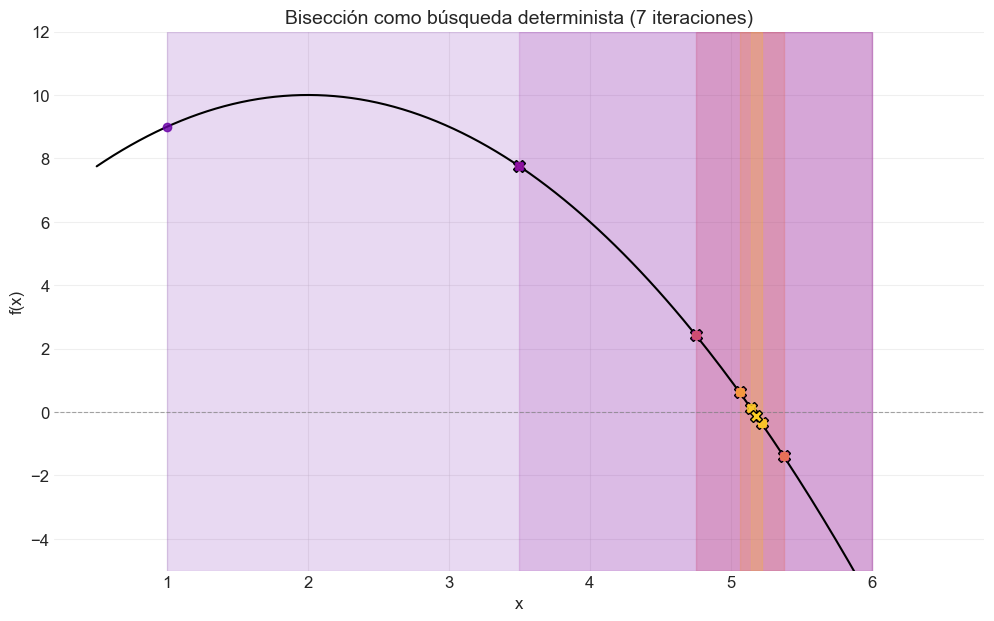

In [2]:
def f(x):
    """Función objetivo: f(x) = -(x-2)**2 + 10"""
    return -(x-2)**2 + 10


def bisection_plot(a_start, b_start, iterations=4):
    """Realiza N iteraciones de Bisección y visualiza recombinación y selección."""
    a, b = a_start, b_start
    
    if f(a) * f(b) >= 0:
        print("Error: f(a) y f(b) deben tener signos opuestos.")
        return
        
    x_vals = np.linspace(a_start - 0.5, b_start + 0.5, 200)
    y_vals = f(x_vals)
    
    plt.figure(figsize=(12, 7))
    plt.plot(x_vals, y_vals, 'k-', linewidth=1.5, label='f(x) = -(x-2)^2 + 10')
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.title(f'Bisección como búsqueda determinista ({iterations} iteraciones)', fontsize=14)
    plt.xlabel('x')
    plt.ylabel('f(x)')
    
    colors = plt.cm.plasma(np.linspace(0.2, 0.9, iterations))
    
    print(f"Iteración |   a    |   b    |   c    | Error_x ≤ (b-a)/2 | Residual |f(c)|")
    print("----------┼--------┼--------┼--------┼-------------------┼-----------------")
    
    for i in range(iterations):
        c = (a + b) / 2
        fc = f(c)
        error_x = (b - a) / 2
        residual = abs(fc)
        
        # Visualización de la "población" {a, b}
        plt.plot([a, b], [f(a), f(b)], 'o', color=colors[i], markersize=6, alpha=0.8)
        
        # Punto medio = recombinación determinista
        plt.plot(c, fc, 'X', color=colors[i], markersize=8, markeredgecolor='black')
        
        # Intervalo sobreviviente = selección elitista
        plt.axvspan(a, b, color=colors[i], alpha=0.15)
        
        print(f"{i+1:4}      | {a:.4f} | {b:.4f} | {c:.4f} |     {error_x:.6f}      |     {residual:.6f}")
        
        # Selección determinista
        if f(a) * fc < 0:
            b = c
        else:
            a = c
            
    final_c = (a + b) / 2
    final_error = (b - a) / 2
    final_residual = abs(f(final_c))

    print(f"\nRaíz aproximada después de {iterations} iteraciones: x = {final_c:.6f}")
    print(f"Cota superior del error en x: {final_error:.6f}")
    print(f"Residual de fitness |f(x)|: {final_residual:.6f}\n")

    plt.ylim(-5, 12)
    plt.grid(True, alpha=0.3)
    plt.show()
    

# Ejecución
bisection_plot(a_start=1.0, b_start=6.0, iterations=7)


### Notas:

#### Error en el espacio de soluciones (genotipo)
En el método de bisección, el error en la variable $x$ está directamente acotado por el tamaño del intervale, de la siguiente manera:

\$\text{error}_x \le \frac{b - a}{2}\$

donde \$[a,b]\$ es el intervalo vigente. Esta cantidad representa una **cota superior del error absoluto** respecto a la raíz real.

Propiedades clave:

- Disminuye **monótonamente** en cada iteración.
- Se reduce de forma **exponencial**:

$e_k = \frac{b_0 - a_0}{2^k}$

Esto significa que la precisión en el espacio de soluciones está garantizada por el algoritmo.

#### Residual en el espacio de fitness (fenotipo)

En análisis numérico, el residual mide qué tan bien una solución candidata satisface la ecuación original, no qué tan cerca está de la solución exacta, es decir:

$r(x) = |f(x)|$

- **No está garantizado que decrezca monótonamente**, incluso cuando el error en $x$  sí lo hace. Esto ocurre porque una pequeña variación en $x$  puede producir cambios no lineales en $f(x)$.

### De lo determinista a lo estocástico

La diferencia del método de bisección con los algoritmos evolutivos reales no es conceptual sino estructural. Cuando el paisaje deja de ser unimodal, continuo o libre de ruido:

- La selección perfecta deja de ser posible  
- La recombinación determinista ya no garantiza progreso  
- La diversidad se vuelve necesaria  

En esos casos necesitamos:

- Poblaciones grandes para mantener diversidad  
- Operadores de variación estocásticos  
- Selección probabilística  
- Mecanismos para evitar convergencia prematura  

Desde esta perspectiva, los algoritmos genéticos pueden verse como una **generalización estocástica** de esquemas de búsqueda iterativa como bisección, diseñada para paisajes multimodales, discontinuos y ruidosos.

---

## 5. Forma canónica mínima del algoritmo genético simple

Un algoritmo genético introduce explícitamente:

- representación genotípica  
- población de soluciones  
- operadores de variación estocásticos  
- selección basada en fitness  

### Esquema básico

Consideremos el ejemplo simple resuelto con el método de bisección: encontrar la raíz de una parábola:

$$f(x) = -(x-2)^2 + 10$$

El algoritmo genético simple se expresa de la siguiente manera:

1. **Inicialización**: Generar una población de $N$ individuos aleatorios, codificados, por ejemplo, como cadenas de bits (genotipos). 

2. **Decodificación**: Transformar cada genotipo en su fenotipo correspondiente; convertir las cadenas de bits, por ejemplo, a números reales.

3. **Evaluación**: Calcular el valor de aptitud de cada fenotipo en la población inicial.

4. **Bucle evolutivo**: Repetir por un número determinado $G$ de generaciones:

   **a. Selección de padres**: Elegir individuos con probabilidad proporcional a su aptitud (torneo, ruleta, ranking, etc.).

   **b. Cruza**: Combinar pares de **genotipos** para producir descendencia. En este punto, cobra importancia la distinción entre genotipo y fenotipo.

   **c. Mutación**: Introducir pequeñas perturbaciones aleatorias en los genotipos.

   **d. Evaluación de la descendencia**: Decodificar los nuevos fenotipos y aplicar la fución de aptitud...

   **e. Reemplazo**: Formar la nueva población (generacional, elitista, steady-state, etc.).

5. **Salida**
   - Devolver el mejor individuo encontrado.

Veamos el caso específico para nuestro problema de la parábola:

In [3]:

def f(x):
    return -(x - 2)**2 + 10

def fitness(x):
    # Negamos el valor absoluto para convertir el problema de minimización
    # de |f(x)| en un problema de maximización: fitness = 0 en la raíz
    return -np.abs(f(x))

# ── Parámetros ────────────────────────────────────────────────────────────────
N_BITS   = 8          # resolución del genotipo: 2^8 = 256 valores posibles en [0,6]
X_MIN, X_MAX = 0, 6  # dominio de búsqueda
POP_SIZE = 6          # tamaño de la población
rng = np.random.default_rng(42)  # generador PCG64 con semilla fija para reproducibilidad

# ── 1. Inicialización ─────────────────────────────────────────────────────────
# Cada individuo es una cadena de N_BITS bits aleatorios (genotipo binario).
# La población inicial cubre el espacio de búsqueda de forma no dirigida.
genotypes = rng.integers(0, 2, size=(POP_SIZE, N_BITS))  # enteros en {0,1}, matriz (POP_SIZE x N_BITS)

print("=" * 55)
print("1. INICIALIZACIÓN — Genotipos (cadenas de bits)")
print("=" * 55)
for i, g in enumerate(genotypes):
    gstr = ''.join(g.astype(str))
    print(f"  Individuo {i+1}: {gstr}")

# ── 2. Decodificación ─────────────────────────────────────────────────────────
def decode(bitstring, x_min=X_MIN, x_max=X_MAX):
    n = len(bitstring)
    # Interpreta la cadena de bits como un entero en base 2
    integer_val = int("".join(bitstring.astype(str)), 2)
    # Mapeo lineal del entero [0, 2^n - 1] al intervalo real [x_min, x_max]
    return x_min + integer_val * (x_max - x_min) / (2**n - 1)

# Aplicamos decode a cada genotipo para obtener su fenotipo (valor real)
phenotypes = np.array([decode(g) for g in genotypes])

print("\n" + "=" * 55)
print("2. DECODIFICACIÓN — Fenotipos (valores reales en [0,6])")
print("=" * 55)
for i, (g, x) in enumerate(zip(genotypes, phenotypes)):
    gstr = ''.join(g.astype(str))
    print(f"  Individuo {i+1}: {gstr}  →  x = {x:.4f}")

# ── 3. Evaluación ─────────────────────────────────────────────────────────────
# Evaluamos f(x) y fitness sobre los fenotipos, no sobre los genotipos.
# Esta separación es central: la función objetivo opera en el espacio del problema,
# no en el espacio de representación.
fit_vals = fitness(phenotypes)
f_vals   = f(phenotypes)

print("\n" + "=" * 55)
print("3. EVALUACIÓN — f(x) y fitness = -|f(x)|")
print("=" * 55)
print(f"  {'Ind':>4}  {'x':>8}  {'f(x)':>10}  {'fitness':>10}")
print("  " + "-" * 40)
for i, (x, fv, fit) in enumerate(zip(phenotypes, f_vals, fit_vals)):
    print(f"  {i+1:>4}  {x:>8.4f}  {fv:>10.4f}  {fit:>10.4f}")

# ── 4a. Selección ─────────────────────────────────────────────────────────────
selection_pressure = 0.5
# Softmax sobre el fitness: asigna probabilidades proporcionales a la aptitud.
# El parámetro selection_pressure controla qué tan sesgada es la distribución:
# valores altos favorecen fuertemente a los mejores (explotación),
# valores bajos distribuyen la probabilidad más uniformemente (exploración).
probs = np.exp(selection_pressure * fit_vals)
probs /= probs.sum()  # normalización para que sumen 1

print("\n" + "=" * 55)
print("4a. SELECCIÓN — Probabilidades de reproducción")
print("=" * 55)
for i, (x, p) in enumerate(zip(phenotypes, probs)):
    bar = "█" * int(p * 40)
    print(f"  Individuo {i+1} (x={x:.4f}):  p={p:.4f}  {bar}")

# Muestreo con reemplazo: un individuo puede ser seleccionado más de una vez
parent_idx = rng.choice(POP_SIZE, size=POP_SIZE, p=probs)
parents_g  = genotypes[parent_idx]
parents_x  = phenotypes[parent_idx]

print(f"\n  Índices de padres seleccionados: {parent_idx + 1}")

# ── 4b. Cruza ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("4b. CRUZA — Recombinación de genotipos (un punto)")
print("=" * 55)

offspring_g = []
# Mezclamos los padres aleatoriamente antes de emparejar,
# para que los pares no dependan del orden de selección
rng.shuffle(parents_g)
pairs = POP_SIZE // 2

for i in range(pairs):
    p1, p2 = parents_g[i], parents_g[i + pairs]
    # Elegimos un punto de corte aleatorio entre posición 1 y N_BITS-1
    # para garantizar que ambos segmentos tengan al menos un bit
    point  = rng.integers(1, N_BITS)
    # Cada hijo hereda el segmento izquierdo de un padre y el derecho del otro
    child1 = np.concatenate([p1[:point], p2[point:]])
    child2 = np.concatenate([p2[:point], p1[point:]])
    offspring_g.extend([child1, child2])
    p1str = ''.join(p1.astype(str))
    p2str = ''.join(p2.astype(str))
    h1str = ''.join(child1.astype(str))
    h2str = ''.join(child2.astype(str))
    print(f"  Par {i+1}:")
    print(f"    P1: {p1str}  +  P2: {p2str}  | corte en posición {point}")
    print(f"    H1: {h1str}")
    print(f"    H2: {h2str}")

offspring_g = np.array(offspring_g)

# ── 4c. Mutación ──────────────────────────────────────────────────────────────
mutation_rate = 0.05  # probabilidad de invertir cada bit individualmente

print("\n" + "=" * 55)
print(f"4c. MUTACIÓN — Flip de bits (p_mut = {mutation_rate})")
print("=" * 55)

mutated_g = offspring_g.copy()
for i, ind in enumerate(mutated_g):
    original = ind.copy()
    # Para cada bit, sorteamos independientemente si muta o no.
    # Con N_BITS=8 y p=0.05, en promedio muta 0.4 bits por individuo.
    mask = rng.random(N_BITS) < mutation_rate
    ind[mask] ^= 1  # XOR con 1: invierte el bit (0→1 o 1→0)
    orig_str = ''.join(original.astype(str))
    mut_str  = ''.join(ind.astype(str))
    if mask.any():
        changed = np.where(mask)[0]
        print(f"  Individuo {i+1}: {orig_str} → {mut_str}  (bit/s {changed+1} invertido/s)")
    else:
        print(f"  Individuo {i+1}: {mut_str}  (sin cambios)")

# ── 4d. Evaluación de la descendencia ────────────────────────────────────────
# Repetimos el ciclo decodificación → evaluación sobre los hijos mutados.
# Nótese que la mutación ocurrió en el genotipo; aquí traducimos su efecto
# al espacio fenotípico para poder calcular el fitness.
offspring_x   = np.array([decode(g) for g in mutated_g])
offspring_fit = fitness(offspring_x)
offspring_f   = f(offspring_x)

print("\n" + "=" * 55)
print("4d. EVALUACIÓN DE LA DESCENDENCIA (DECODIFICADA)")
print("=" * 55)
print(f"  {'Ind':>4}  {'genotipo':>10}  {'x':>8}  {'f(x)':>10}  {'fitness':>10}")
print("  " + "-" * 52)
for i, (g, x, fv, fit) in enumerate(zip(mutated_g, offspring_x, offspring_f, offspring_fit)):
    gstr = ''.join(g.astype(str))
    print(f"  {i+1:>4}  {gstr:>10}  →  {x:>8.4f}  {fv:>10.4f}  {fit:>10.4f}")

# ── 4e. Reemplazo generacional ────────────────────────────────────────────────
# La descendencia reemplaza completamente a la generación anterior.
# No se conserva ningún individuo parental, ni siquiera el mejor
# (ausencia de elitismo). Esto puede causar pérdida de la mejor solución
# encontrada hasta el momento.
print("\n" + "=" * 55)
print("4e. REEMPLAZO — Nueva generación")
print("=" * 55)
best_parent = phenotypes[np.argmax(fit_vals)]
best_child  = offspring_x[np.argmax(offspring_fit)]
print(f"  Mejor individuo — Generación 0: x = {best_parent:.4f}  fitness = {np.max(fit_vals):.4f}")
print(f"  Mejor individuo — Generación 1: x = {best_child:.4f}  fitness = {np.max(offspring_fit):.4f}")

1. INICIALIZACIÓN — Genotipos (cadenas de bits)
  Individuo 1: 01100101
  Individuo 2: 00111111
  Individuo 3: 10101001
  Individuo 4: 11011000
  Individuo 5: 01101101
  Individuo 6: 01100101

2. DECODIFICACIÓN — Fenotipos (valores reales en [0,6])
  Individuo 1: 01100101  →  x = 2.3765
  Individuo 2: 00111111  →  x = 1.4824
  Individuo 3: 10101001  →  x = 3.9765
  Individuo 4: 11011000  →  x = 5.0824
  Individuo 5: 01101101  →  x = 2.5647
  Individuo 6: 01100101  →  x = 2.3765

3. EVALUACIÓN — f(x) y fitness = -|f(x)|
   Ind         x        f(x)     fitness
  ----------------------------------------
     1    2.3765      9.8583     -9.8583
     2    1.4824      9.7320     -9.7320
     3    3.9765      6.0936     -6.0936
     4    5.0824      0.4991     -0.4991
     5    2.5647      9.6811     -9.6811
     6    2.3765      9.8583     -9.8583

4a. SELECCIÓN — Probabilidades de reproducción
  Individuo 1 (x=2.3765):  p=0.0084  
  Individuo 2 (x=1.4824):  p=0.0090  
  Individuo 3 (x=3.97

<br>

### Diferencias estructurales con bisección

| Aspecto | Bisección | Algoritmo genético |
|--------|-----------|-------------------|
| Representación | Directa ($x$) | Genotipo → Fenotipo |
| Población | 2 individuos | $N \gg 2$ |
| Variación | Determinista (punto medio) | Estocástica (cruza + mutación) |
| Selección | Determinista, perfecta | Probabilística |
| Información del paisaje | Cambio de signo | Sólo fitness |
| Cota de error | Sí | No garantizada |

La clave del éxito de este enfoque es su **carácter poblacional**.


En consecuencia:

- Bisección **reduce sistemáticamente** el espacio de búsqueda.  
- Un algoritmo genético **explora** el espacio de soluciones manteniendo diversidad.  

Esto lo hace adecuado para paisajes multimodales, discontinuos o ruidosos, donde no existe información estructural suficiente para aplicar métodos deterministas.

### Un AG mínimo en el mismo paisaje

Ahora resolvemos el mismo problema para $f(x) = -(x-2)^2 + 10$, pero con un **algoritmo genético de codificación binaria**, la representación canónica de los AGS clásicos.

A diferencia del ejemplo anterior de valores reales, aquí el genotipo y el fenotipo son espacios distintos: cada individuo existe como una cadena de 8 bits que debe *decodificarse* para obtener un valor real en $[0, 6]$. Esta separación es importante: es lo que permite que los operadores genéticos (cruza, mutación) operen sobre una representación uniforme e independiente del dominio del problema.

Con $2^8 = 256$ puntos posibles, la resolución del genotipo en el rango de búsqueda es $\frac{6}{255} \approx 0.024$. Este es el **límite de precisión estructural** del sistema: ningún operador, por sofisticado que sea, puede producir una solución más precisa que la que permite la representación. Aumentar `N_BITS` mejoraría la resolución sin modificar ninguno de los operadores.

Los operadores son:
- **Cruza de un punto**: dos genotipos intercambian segmentos en una posición aleatoria, combinando bloques de información de ambos padres.
- **Mutación por flip**: cada bit se invierte de forma independiente con probabilidad $p_{\text{mut}}$, introduciendo perturbaciones locales en el genotipo.


In [4]:
rng = np.random.default_rng(42)

AGS BINARIO — BÚSQUEDA DE RAÍCES DE f(x) = -(x-2)² + 10
Dominio: [0, 6]  |  Raíz objetivo: x* ≈ 5.162
Resolución genotípica: 6 / 255 ≈ 0.0235  (N_BITS = 8)
  Gen   1 | mejor x = 5.12941 | f(x) = +0.20678 | fitness = -0.20678
  Gen   6 | mejor x = 5.12941 | f(x) = +0.20678 | fitness = -0.20678
  Gen  11 | mejor x = 5.15294 | f(x) = +0.05896 | fitness = -0.05896
  Gen  16 | mejor x = 5.15294 | f(x) = +0.05896 | fitness = -0.05896
  Gen  20 | mejor x = 5.15294 | f(x) = +0.05896 | fitness = -0.05896

RESULTADO FINAL
  Mejor x encontrado : 5.152941
  f(x)               : +0.058962  (objetivo: 0.000000)
  Error respecto x*  : 0.009336
  Raíz exacta        : 5.162278


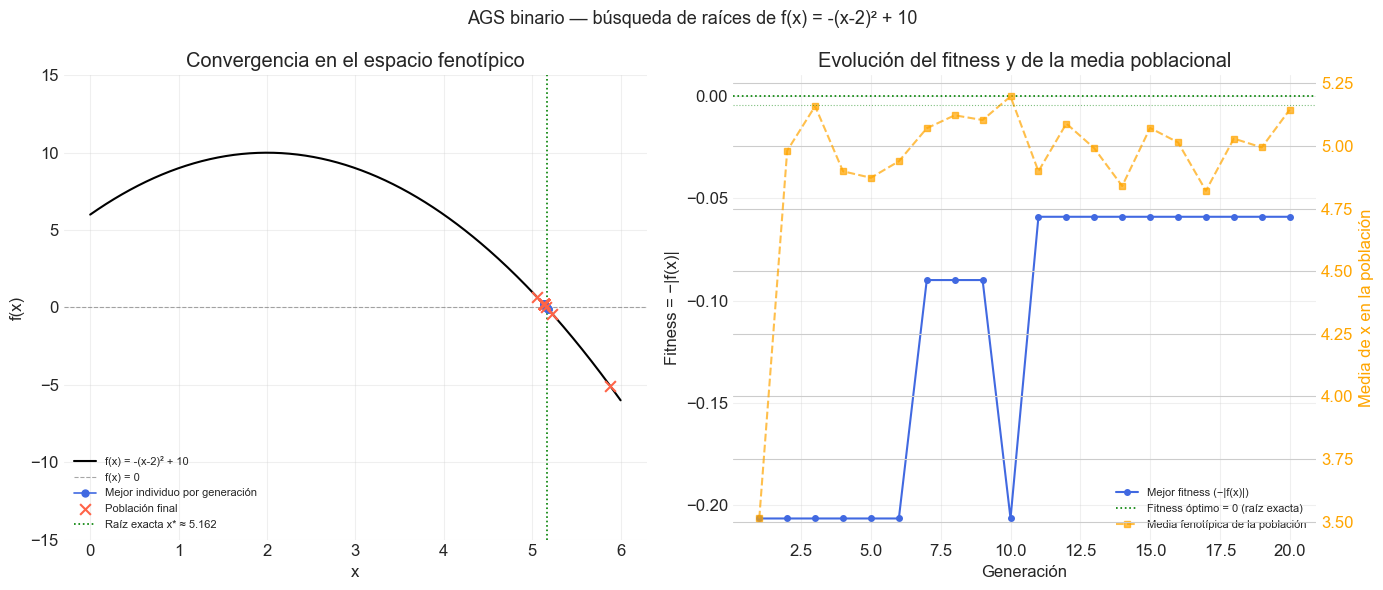

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Búsqueda de raíces con AGS de codificación binaria
#
# Objetivo: encontrar x* tal que f(x*) = 0, donde f(x) = -(x-2)^2 + 10.
# Las raíces exactas son x = 2 ± √10 ≈ {-1.162, 5.162}.
# Dado que el dominio es [0, 6], la raíz buscada es x* ≈ 5.162.
#
# ══════════════════════════════════════════════════════════════════════════════

def f(x):
    return -(x - 2)**2 + 10

def fitness(x):
    # fitness = 0 en la raíz; negativo en cualquier otro punto.
    return -np.abs(f(x))

# ── Parámetros ────────────────────────────────────────────────────────────────
N_BITS           = 8      # resolución del genotipo: 2^8 = 256 puntos en [0, 6]
X_MIN, X_MAX     = 0, 6   # dominio de búsqueda
POP_SIZE         = 20     # individuos por generación
GENERATIONS      = 20     # número de ciclos evolutivos
MUTATION_RATE    = 0.02   # probabilidad de flip por bit (8 bits x 0.02 ≈ 0.16 bits mutados/individuo)
SEL_PRESSURE     = 0.5    # sesgo de la distribución de selección

# ── Decodificación ────────────────────────────────────────────────────────────
def decode(bitstring, x_min=X_MIN, x_max=X_MAX):
    """Convierte una cadena de bits en un valor real mediante mapeo lineal."""
    n           = len(bitstring)
    integer_val = int("".join(bitstring.astype(str)), 2)
    return x_min + integer_val * (x_max - x_min) / (2**n - 1)

def decode_population(pop):
    return np.array([decode(ind) for ind in pop])

# ── 1. Inicialización ─────────────────────────────────────────────────────────
# Cada individuo es una cadena aleatoria de N_BITS bits.
# La población cubre el espacio de búsqueda de forma no dirigida.
population = rng.integers(0, 2, size=(POP_SIZE, N_BITS))

# Registros históricos para visualización posterior
history_best_x   = []   # mejor x por generación
history_best_fit = []   # mejor fitness por generación
history_mean_x   = []   # media fenotípica de la población

print("=" * 60)
print("AGS BINARIO — BÚSQUEDA DE RAÍCES DE f(x) = -(x-2)² + 10")
print(f"Dominio: [{X_MIN}, {X_MAX}]  |  Raíz objetivo: x* ≈ 5.162")
print(f"Resolución genotípica: 6 / 255 ≈ {6/255:.4f}  (N_BITS = {N_BITS})")
print("=" * 60)

# ── Bucle evolutivo ───────────────────────────────────────────────────────────
for gen in range(GENERATIONS):

    # ── 2. Decodificación y evaluación ────────────────────────────────────────
    phenotypes = decode_population(population)
    fit_vals   = fitness(phenotypes)

    # Registramos estado de esta generación
    best_idx = np.argmax(fit_vals)
    history_best_x.append(phenotypes[best_idx])
    history_best_fit.append(fit_vals[best_idx])
    history_mean_x.append(np.mean(phenotypes))

    # Informe por generación (cada 5 para no saturar la salida)
    if gen % 5 == 0 or gen == GENERATIONS - 1:
        best_x   = phenotypes[best_idx]
        best_f   = f(best_x)
        best_fit = fit_vals[best_idx]
        print(f"  Gen {gen+1:>3} | mejor x = {best_x:.5f} | f(x) = {best_f:+.5f} | fitness = {best_fit:.5f}")

    # ── 3. Selección (softmax) ────────────────────────────────────────────────
    probs  = np.exp(SEL_PRESSURE * fit_vals)
    probs /= probs.sum()
    parent_idx = rng.choice(POP_SIZE, size=POP_SIZE, p=probs)
    parents    = population[parent_idx]

    # ── 4. Cruza de un punto ──────────────────────────────────────────────────
    # Mezclamos para que los pares sean independientes del orden de selección.
    rng.shuffle(parents)
    offspring = []
    for i in range(POP_SIZE // 2):
        p1, p2 = parents[i], parents[i + POP_SIZE // 2]
        # Punto de corte en [1, N_BITS-1]: garantiza al menos un bit de cada padre
        point  = rng.integers(1, N_BITS)
        child1 = np.concatenate([p1[:point], p2[point:]])
        child2 = np.concatenate([p2[:point], p1[point:]])
        offspring.extend([child1, child2])
    offspring = np.array(offspring)

    # ── 5. Mutación (flip de bits) ────────────────────────────────────────────
    # Cada bit se invierte con probabilidad MUTATION_RATE, de forma independiente.
    mask = rng.random(offspring.shape) < MUTATION_RATE
    offspring[mask] ^= 1   # XOR invierte el bit: 0 → 1 ó 1 → 0

    # ── 6. Reemplazo generacional ─────────────────────────────────────────────
    # La descendencia reemplaza completamente a la generación anterior.
    # Sin elitismo: el mejor individuo puede perderse entre generaciones.
    population = offspring

# Evaluación final de la última generación
phenotypes_final = decode_population(population)
fit_final        = fitness(phenotypes_final)
best_final_x     = phenotypes_final[np.argmax(fit_final)]
best_final_f     = f(best_final_x)

print()
print("=" * 60)
print("RESULTADO FINAL")
print("=" * 60)
print(f"  Mejor x encontrado : {best_final_x:.6f}")
print(f"  f(x)               : {best_final_f:+.6f}  (objetivo: 0.000000)")
print(f"  Error respecto x*  : {abs(best_final_x - (2 + 10**0.5)):.6f}")
print(f"  Raíz exacta        : {2 + 10**0.5:.6f}")

# ── Visualización ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("AGS binario — búsqueda de raíces de f(x) = -(x-2)² + 10", fontsize=13)

# ── Panel izquierdo: paisaje de búsqueda ──────────────────────────────────────
ax = axes[0]
x_plot  = np.linspace(X_MIN, X_MAX, 400)
y_plot  = f(x_plot)

ax.plot(x_plot, y_plot, 'k-', linewidth=1.5, label='f(x) = -(x-2)² + 10')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='f(x) = 0')

# Trayectoria del mejor individuo generación a generación
best_x_arr   = np.array(history_best_x)
best_f_arr   = f(best_x_arr)
ax.plot(best_x_arr, best_f_arr, 'o-', color='royalblue', markersize=5,
        linewidth=1.2, label='Mejor individuo por generación', zorder=3)

# Población final: muestra convergencia o diversidad residual
ax.scatter(phenotypes_final, f(phenotypes_final), marker='x', s=60,
           color='tomato', zorder=4, label='Población final')

# Raíz exacta de referencia
x_root = 2 + 10**0.5
ax.axvline(x_root, color='green', linestyle=':', linewidth=1.2,
           label=f'Raíz exacta x* ≈ {x_root:.3f}')

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Convergencia en el espacio fenotípico')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-15, 15)

# ── Panel derecho: convergencia del fitness ───────────────────────────────────
ax2 = axes[1]
gens = np.arange(1, GENERATIONS + 1)

ax2.plot(gens, history_best_fit, 'o-', color='royalblue', markersize=4,
         label='Mejor fitness (−|f(x)|)')
ax2.axhline(0, color='green', linestyle=':', linewidth=1.2,
            label='Fitness óptimo = 0 (raíz exacta)')

# Eje secundario: evolución de la media fenotípica
ax2b = ax2.twinx()
ax2b.plot(gens, history_mean_x, 's--', color='orange', markersize=4,
          alpha=0.7, label='Media fenotípica de la población')
ax2b.axhline(x_root, color='green', linestyle=':', linewidth=0.8, alpha=0.5)
ax2b.set_ylabel('Media de x en la población', color='orange')
ax2b.tick_params(axis='y', labelcolor='orange')

ax2.set_xlabel('Generación')
ax2.set_ylabel('Fitness = −|f(x)|')
ax2.set_title('Evolución del fitness y de la media poblacional')
ax2.grid(True, alpha=0.3)

# Leyenda combinada de ambos ejes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

Estas gráficas muestran la evolución del AGS sobre el problema de prueba. La segunda gráfica es la más interesante. A diferencia de bisección, donde el error cae monótonamente por construcción, aquí la trayectoria del fitness es irregular: hay generaciones donde el mejor individuo no mejora, e incluso puede empeorar si el operador de mutación degrada al mejor padre sin que la selección lo compense.

Lo que sí se desarrolla de forma clara es la **presión de selección acumulada**: la media fenotípica de la población (eje derecho, en naranja) se mueve progresivamente hacia la región de la raíz, reflejando que la selección probabilística desplaza el centro de masa poblacional aunque no garantice progreso individual en cada paso.

El salto abrupto de fitness visible en la gráfica es característico de los AGS binarios: ocurre cuando la cruza produce un genotipo que, al decodificarse, cae significativamente más cerca de la raíz que cualquier individuo previo. Es un evento discreto, no una mejora gradual.

El error residual final ($|f(x)|$) no refleja un fallo del algoritmo sino el **piso de resolución genotípica**: el punto discreto más cercano a la raíz en la grilla de 256 valores dista $\approx 0.01$ de $x^* \approx 5.162$. El método de bisección no tiene problema para mejroar el resultado indefinidamente porque opera en el continuo. El AGS binario no puede, y esa diferencia estructural es precisamente lo quese meustra en la comparación.

---

## 6. Pool genético y diversidad

La población en cada generación constituye un **pool genético**: un muestreo del espacio de búsqueda que el algoritmo mantiene y transforma iterativamente.

La **diversidad genética** mide la dispersión de los genotipos en ese pool. Es la tensión central de cualquier algoritmo evolutivo:

- Alta diversidad → exploración global del espacio de búsqueda
- Baja diversidad → explotación local de las mejores soluciones conocidas

Esta tensión no se resuelve, sino que se administra. Un algoritmo bien calibrado mantiene suficiente diversidad para no quedar atrapado en óptimos locales, pero concentra progresivamente la búsqueda en las regiones prometedoras.

Los operadores actúan sobre la diversidad de formas opuestas y complementarias:

- **Selección** la reduce: favorece sistemáticamente a los individuos más aptos, empujando a la población hacia regiones de alto fitness.
- **Mutación** la introduce: genera nuevos alelos (variantes en posiciones del genotipo) que no existían en la población actual.
- **Cruza** la redistribuye: no crea información nueva, pero recombina bloques de genotipos existentes, produciendo nuevas combinaciones a partir de material ya presente.

La pérdida irreversible de diversidad se llama **convergencia prematura**: la población colapsa en torno a un óptimo local antes de haber explorado suficientemente el espacio. Es el principal modo de fallo de los AGS, y ocurre cuando la presión de selección supera la capacidad de la mutación para reponer variación. Ese ajuste que debemos hacer entre estos dos factores, presión selectiva y mutación, es una de las críticas principales a los algoritmos genéticos.

### El espacio genotípico como espacio de búsqueda real

El algoritmo no opera directamente sobre el espacio del problema sino sobre el **espacio genotípico** inducido por la representación. Esta distinción tiene consecuencias concretas:

- La representación binaria de 8 bits que hemos empleado en nuestros ejemplos previos define una grilla de 256 puntos en el rango $[0, 6]$: ese es el universo accesible, no el continuo real.
- La cruza de un punto opera de forma aparentemente simétrica: elige una posición aleatoria en el genotipo y construye dos hijos intercambiando los segmentos de dos padres. Sin embargo, esta simetría en el espacio genotípico produce una asimetría profunda en el espacio fenotípico que tiene consecuencias directas sobre qué regiones del dominio puede explorar el algoritmo.
- La mutación por flip es simétrica en el espacio genotípico, pero su efecto fenotípico no lo es: invertir el bit más significativo, en nuestro ejemplo, desplaza $x$ hasta en $\approx 3$ unidades, mientras que invertir el menos significativo lo desplaza solo $\approx 0.024$.

Por ello, la elección de representación no es un detalle de implementación sino una **decisión de diseño** que determina qué regiones del espacio son fáciles de alcanzar, qué tan fina puede ser la solución, y qué tipo de estructura puede explotar la cruza.

---

## 7. AGS en paisaje multimodales bidimensional

Hasta ahora el AGS operó sobre $f(x) = -(x-2)^2 + 10$: un paisaje unimodal, continuo y perfectamente bien comportado. En un paisaje unimodal, bisección es mejor opción que un algoritmo genético: converge más rápido, tiene garantías formales y no presenta parámetros que calibrar.

Veamos ahora un par de ejemplos más interesantes.

### Un paisaje multimodal (a modo)
Consideremos la sigueinte función objetivo:

$$f(x, y) = \sin(x)\cos(2y) + 0.2(x^2 + y^2) + 0.5\sin(3x)\cos(3y)$$

La función objetivo es ahora bidimensional y multimodal. El término $0.2(x^2 + y^2)$ actúa como regularización suave: penaliza soluciones alejadas del origen y garantiza que la función sea acotada en $[-3, 3]^2$, pero no elimina los múltiples mínimos locales introducidos por los términos sinusoidales. 

<p align="center">
  <img src="images/multimodal_function.png" width="80%">
</p>

El paisaje resultante tiene valles, crestas y trampas locales que ningún método determinista basado en información local puede atravesar sin quedar atrapado. En este caso no hay cambio de signo que explotar, no hay gradiente disponible, y el problema tiene dos dimensiones. El AGS, en cambio, opera con la misma lógica de siempre: mantener una población diversa, seleccionar por fitness, recombinar y mutar. El paisaje rugoso no cambia el algoritmo, solo hace visible por qué la diversidad poblacional es necesaria.

La función multimodal ad hoc que estamso utilizando aquí no es una función típica de *benchmarking*, como lo son Schwefel, Rastrigin, Ackley, Griewank o Rosenbrock, y eso tiene implicaciones prácticas: como no tenemos un mínimo global conocido ni propiedades analíticas bien caracterizadas no es posible medir error absoluto, distancia al óptimo ni tasa de convergencia real. La evaluación se reduce a observaciones cualitativas: “parece converger”, “explora varias regiones”, “se estanca”. Esto impide comparar configuraciones del algoritmo de forma reproducible. Sin embargo, es más simple que las funciones de *benchmarking* y permite visualizar mejor el esapcio de búsqueda.


### La función de Schwefel

El segundo ejemplo, la función de Schwefel es uno de los benchmarks más utilizados en optimización global. En $d$ dimensiones se define como:

$$f(\mathbf{x}) = 418.9829 \cdot d - \sum_{i=1}^{d} x_i \sin\!\left(\sqrt{|x_i|}\right)$$

con dominio estándar $x_i \in [-500, 500]$ y mínimo global en $x_i^* = 420.9687$ para toda dimensión $i$, donde $f(x^*) = 0$.

<p align="center">
  <img src="images/schwefel_function.png" width="80%">
</p>

El término $418.9829 \cdot d$ es una constante de normalización que desplaza el mínimo global exactamente a cero, facilitando la interpretación del residual como error absoluto.

La función de Schwefel es considerada una de las funciones de prueba más difíciles, lo cuál no es accidental sino estructural. Su dificultad proviene de la interacción entre el término sinusoidal y el dominio amplio. La componente $g(x) = x\sin(\sqrt{|x|})$ tiene una forma característica: oscila con amplitud creciente a medida que $|x|$ aumenta, produciendo una secuencia de valles cada vez más profundos conforme uno se aleja del origen. 


<p align="center">
  <img src="images/schwefel_function_sin.png" width="600">
</p>

El mínimo global de $g$ en $[-500, 500]$ se encuentra en $x \approx 420.97$, pero antes de llegar ahí la función atraviesa decenas de mínimos locales de profundidad comparable.

Esto crea dos propiedades que la hacen especialmente engañosa para los algoritmos de búsqueda:

La primera es la **distancia al óptimo**. El mínimo global está en $x \approx 421$, un valor positivo moderado dentro del dominio. No está en el centro, no está en los bordes, y no hay ninguna característica geométrica obvia que lo distinga de los mínimos locales vecinos a simple vista. Un algoritmo que muestrea el dominio uniformemente no tiene razón estructural para visitar esa región primero.

La segunda es la **topografía engañosa**. Los valles más prominentes visualmente —los más anchos y de paredes más suaves— se encuentran cerca de los extremos del dominio, alrededor de $x \approx \pm 300$ y $x \approx \pm 430$. El gradiente local en esas regiones apunta hacia ellos, no hacia el mínimo global. Un método de descenso de gradiente iniciado desde un punto aleatorio tiene alta probabilidad de terminar en uno de esos valles periféricos sin llegar nunca a $x^* \approx 421$.

En dos dimensiones estas propiedades se combinan de forma multiplicativa: cada dimensión tiene su propio paisaje sinusoidal, y el mínimo global requiere que ambas coordenadas estén simultáneamente cerca de $420.97$. La probabilidad de que una búsqueda local llegue ahí desde un punto arbitrario es baja, lo que hace que la diversidad poblacional inicial sea crítica.

#### Lo que hace verificable el benchmark

A diferencia de funciones construidas ad hoc, Schwefel tiene tres propiedades que la hacen útil como referencia:

El mínimo global es **conocido analíticamente**: $f(420.97, \ldots, 420.97) = 0$. Esto permite medir el error real al final de cada ejecución, no solo el valor de fitness relativo.

Es **escalable en dimensión**: la misma definición funciona en 2, 10 o 1000 dimensiones, lo que permite estudiar cómo degrada el rendimiento del AGS a medida que el espacio crece. En 2D es resoluble con parámetros razonables; en dimensiones altas se convierte en un problema abierto.

Está **ampliamente documentada en la literatura**: existen resultados publicados de decenas de algoritmos distintos sobre esta función, lo que permite comparar directamente sin necesidad de reimplementar métodos alternativos.

Estas propiedades son las que distinguen un *benchmark* de un ejemplo: no solo ilustra un fenómeno, sino que permite medir, comparar y reproducir.


### Cambios de representación y operadores

Estos ejemplos usan **representación en valores reales** (genotipo = fenotipo) en lugar de codificación binaria para tener un espacio de búsqueda más manejable. En general, en espacios continuos de dimensión moderada, la representación real es más natural y permite operadores con mejor comportamiento.

La **selección cambia de softmax a torneo**: en cada selección se eligen $k = 3$ individuos al azar y gana el de mayor fitness. El torneo no requiere calibrar una temperatura y es robusto cuando las diferencias de fitness son muy grandes, situación habitual en paisajes multimodales donde los valles son profundos y los individuos atrapados en ellos tienen fitness muy inferior al de los que están cerca del óptimo global.

La **cruza es por mezcla** (BLX simplificado): cada hijo es una combinación convexa de dos padres con peso aleatorio $\alpha \sim U(0,1)$:

$$\text{hijo} = \alpha \cdot p_1 + (1 - \alpha) \cdot p_2$$

A diferencia de la cruza de un punto, que intercambia segmentos discretos, BLX produce puntos intermedios en el espacio continuo, explorando el segmento entre ambos padres. En dos dimensiones esto tiene un sentido geométrico claro: el hijo cae en algún lugar del segmento que une a sus padres en el plano $(x, y)$. Por ejemplo si $p_1 = (2, 5)$ y $p_2 = (8, 1)$ y si $\alpha = 0.25$:

$$\text{hijo} = 0.25(2,5) + 0.75(8,1) = (6.5, 2)$$

Este punto está sobre la recta que conecta a los padres.

La **mutación es gaussiana**: cada coordenada se perturba con ruido $\mathcal{N}(0, \sigma)$ con probabilidad $p_{\text{mut}}$ independiente. Un $\sigma$ grande explora lejos del padre; un $\sigma$ pequeño refina localmente. A diferencia del flip de bits, cuyo efecto fenotípico depende de la posición del bit mutado, la mutación gaussiana produce perturbaciones de magnitud controlable y predecible en el espacio del problema.

Por último, este ejemplo incorpora **elitismo**: los dos mejores individuos de cada generación pasan directamente a la siguiente sin modificación. Es la estrategia más simple para evitar que la mejor solución encontrada se pierda por deriva generacional, y su efecto es visible en la curva de fitness, que nunca retrocede en el mejor individuo aunque sí puede hacerlo en la media poblacional.

Veamos el algoritmo funcionando:

In [6]:
# ════════════════════════════════════════════════════════════════════════
# AGS en representación real — operadores comunes
# ════════════════════════════════════════════════════════════════════════

def tournament_select(pop, fit_vals, k, rng):
    """Selección por torneo de tamaño k."""
    idx = rng.choice(len(pop), size=k, replace=False)
    return pop[idx[np.argmax(fit_vals[idx])]]

def blx_crossover(p1, p2, rng):
    """Cruza BLX (convexa)."""
    alpha = rng.random()
    return alpha * p1 + (1 - alpha) * p2

def gaussian_mutation(offspring, rate, sigma, xy_min, xy_max, rng):
    """Mutación gaussiana independiente por coordenada."""
    mask      = rng.random(offspring.shape) < rate
    noise     = rng.normal(0, sigma, size=offspring.shape)
    offspring = offspring + mask * noise
    return np.clip(offspring, xy_min, xy_max)

def run_ags(fitness_fn, xy_min, xy_max, pop_size, generations,
            mutation_sigma, mutation_rate, tournament_k, elite_n,
            snap_gens, seed=42):

    rng        = np.random.default_rng(seed)
    population = rng.uniform(xy_min, xy_max, size=(pop_size, 2))

    history_best_fit  = []
    history_mean_fit  = []
    history_worst_fit = []
    history_best_xy   = []
    history_diversity = []
    snapshots         = {}

    for gen in range(generations):

        fit_vals  = fitness_fn(population)
        best_idx  = np.argmax(fit_vals)
        diversity = np.mean(np.std(population, axis=0))

        history_best_fit.append(fit_vals[best_idx])
        history_mean_fit.append(fit_vals.mean())
        history_worst_fit.append(fit_vals.min())
        history_best_xy.append(population[best_idx].copy())
        history_diversity.append(diversity)

        if gen in snap_gens:
            snapshots[gen] = population.copy()

        elite_idx = np.argsort(fit_vals)[-elite_n:]
        elites    = population[elite_idx].copy()

        offspring = []
        for _ in range(pop_size - elite_n):
            p1    = tournament_select(population, fit_vals, tournament_k, rng)
            p2    = tournament_select(population, fit_vals, tournament_k, rng)
            child = blx_crossover(p1, p2, rng)
            offspring.append(child)
        offspring = np.array(offspring)

        offspring = gaussian_mutation(offspring, mutation_rate, mutation_sigma,
                                      xy_min, xy_max, rng)

        population = np.vstack([elites, offspring])

    fit_final = fitness_fn(population)
    snapshots[generations - 1] = population.copy()

    return {
        'history_best_fit' : history_best_fit,
        'history_mean_fit' : history_mean_fit,
        'history_worst_fit': history_worst_fit,
        'history_best_xy'  : np.array(history_best_xy),
        'history_diversity': history_diversity,
        'snapshots'        : snapshots,
        'final_population' : population,
        'final_fit'        : fit_final,
    }

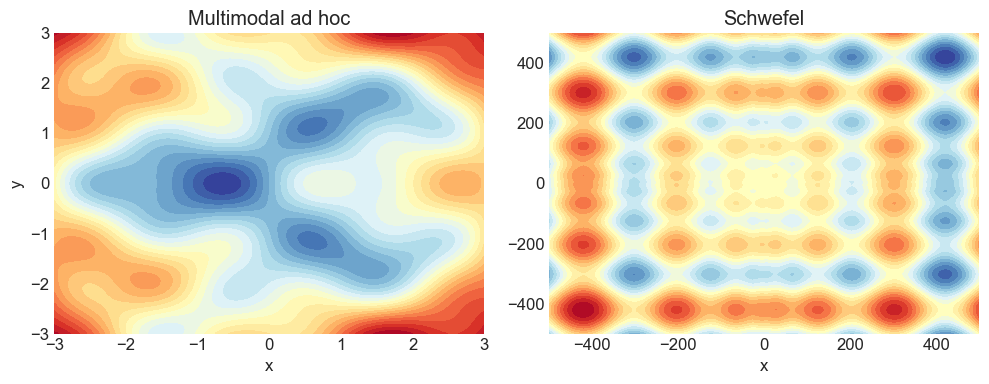

In [7]:
# ════════════════════════════════════════════════════════════════════════
# Funciones objetivo
# ════════════════════════════════════════════════════════════════════════

def f_multimodal(x, y):
    return np.sin(x) * np.cos(2*y) + 0.2*(x**2 + y**2) + 0.5*np.sin(3*x)*np.cos(3*y)

def f_schwefel(xy):
    d   = len(xy)
    return 418.9829 * d - np.sum(xy * np.sin(np.sqrt(np.abs(xy))))

def f_schwefel_2d(x, y):
    return 418.9829 * 2 - (x * np.sin(np.sqrt(np.abs(x))) +
                           y * np.sin(np.sqrt(np.abs(y))))

# ── Visualización de las tres funciones ─────────────────────────────────

fig = plt.figure(figsize=(15, 4))

# Multimodal ad hoc
ax1 = fig.add_subplot(1, 3, 1)
gx = np.linspace(-3, 3, 200)
gy = np.linspace(-3, 3, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = f_multimodal(GX, GY)
ax1.contourf(GX, GY, GZ, levels=25, cmap='RdYlBu_r')
ax1.set_title("Multimodal ad hoc")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# Schwefel (vista local reducida para comparar forma)
ax2 = fig.add_subplot(1, 3, 2)
gx = np.linspace(-500, 500, 200)
gy = np.linspace(-500, 500, 200)
GX, GY = np.meshgrid(gx, gy)
GZ = f_schwefel_2d(GX, GY)
ax2.contourf(GX, GY, GZ, levels=25, cmap='RdYlBu_r')
ax2.set_title("Schwefel")
ax2.set_xlabel("x")


plt.tight_layout()
plt.show()


Las superficies mostradas en estas  gráficas corresponden a dos paisajes de aptitud con propiedades distintas y objetivos complementarios dentro del análisis del algoritmo genético.

En la primera gráfica se observa una superficie suave, continua y claramente multimodal. La combinación de términos sinusoidales genera una estructura ondulada con múltiples valles y crestas, mientras que el término cuadrático introduce una tendencia global creciente hacia los bordes del dominio.

Visualmente se distinguen:

- Varios **mínimos locales** distribuidos de forma regular  
- Cuencas de atracción amplias y relativamente suaves  
- Un gradiente bien definido dentro de cada valle  
- Interacción entre variables $x$ y $y$, lo que produce patrones diagonales en la superficie  

El mínimo global no está caracterizado analíticamente, pero en la gráfica puede identificarse como el valle más profundo dentro de la región central. 

La segunda gráfica muestra un paisaje mucho más engañoso. Aunque la superficie parece relativamente suave, los **mínimos locales dominantes** se encuentran lejos del mínimo global. Además, el óptimo no está en el centro del dominio sino desplazado hacia una región específica.

En la visualización se aprecia que:

- las zonas cercanas a los bordes presentan pendientes poco informativas  
- existen valles profundos que no conducen al óptimo global  
- la topología global no es intuitiva a partir de la información local  

El resutado dle algoritmo genético sobre la función multimodale es

In [8]:
# ════════════════════════════════════════════════════════════════════════
# Función multimodal simple
# ════════════════════════════════════════════════════════════════════════

A_MIN, A_MAX = -3.0, 3.0
A_POP        = 40
A_GENS       = 40
A_SIGMA      = 0.3
A_MUT_RATE   = 0.4
A_K          = 3
A_ELITE      = 2
A_SNAPS      = [0, 1, 3, 8, 20, A_GENS - 1]

def fitness_multimodal(pop):
    return -f_multimodal(pop[:, 0], pop[:, 1])

res_A = run_ags(fitness_multimodal, A_MIN, A_MAX,
                A_POP, A_GENS, A_SIGMA, A_MUT_RATE,
                A_K, A_ELITE, A_SNAPS)

best_A    = res_A['final_population'][np.argmax(res_A['final_fit'])]
f_best_A  = f_multimodal(best_A[0], best_A[1])

print("Mejor solución multimodal:")
print(f"x = {best_A[0]:+.5f}, y = {best_A[1]:+.5f}")
print(f"f(x,y) = {f_best_A:+.6f}")

Mejor solución multimodal:
x = -0.64588, y = -0.00010
f(x,y) = -0.985201


Este resultado indica que el algoritmo genético logró concentrar la población en una de las cuencas más profundas observadas en la gráfica 3D de la función *ad hoc*. Al comparar visualmente la superficie, ese punto coincide con el valle más pronunciado dentro de la región central del dominio, lo que sugiere una convergencia efectiva hacia el mejor mínimo accesible durante la búsqueda. Dado que la función no tiene un óptimo global conocido, no puede asegurarse que sea el mínimo absoluto, pero sí que corresponde al valle más profundo identificado por el algoritmo en las visualizaciones.

El resultado sobre la función de Schwefel, por otra parte es

In [9]:
# ════════════════════════════════════════════════════════════════════════
# Función de Schwefel
# ════════════════════════════════════════════════════════════════════════

B_MIN, B_MAX = -500.0, 500.0
B_POP        = 150
B_GENS       = 150
B_SIGMA      = 100.0
B_MUT_RATE   = 0.5
B_K          = 3
B_ELITE      = 3
B_SNAPS      = [0, 1, 10, 30, 80, B_GENS - 1]
SCHWEFEL_OPTIMUM = np.array([420.9687, 420.9687])

def fitness_schwefel(pop):
    return np.array([-f_schwefel(ind) for ind in pop])

res_B = run_ags(fitness_schwefel, B_MIN, B_MAX,
                B_POP, B_GENS, B_SIGMA, B_MUT_RATE,
                B_K, B_ELITE, B_SNAPS)

best_B   = res_B['final_population'][np.argmax(res_B['final_fit'])]
f_best_B = f_schwefel(best_B)
err_B    = np.linalg.norm(best_B - SCHWEFEL_OPTIMUM)

print("Mejor solución Schwefel:")
print(f"x = {best_B[0]:+.3f}, y = {best_B[1]:+.3f}")
print(f"f(x,y) = {f_best_B:+.4f}")
print(f"Error a x* = {err_B:.3f}")

Mejor solución Schwefel:
x = +421.015, y = +420.909
f(x,y) = +0.0008
Error a x* = 0.076


Este resultado muestra que el algoritmo genético convergió muy cerca del mínimo global conocido de la función de Schwefel en $(420.9687,\;420.9687)$. El error euclidiano reportado ($0.076$) indica que la solución encontrada se ubica dentro de una vecindad muy pequeña del óptimo, lo que confirma una búsqueda efectiva en un paisaje altamente engañoso. Dado que los mínimos locales dominantes de Schwefel se encuentran alejados del óptimo global, este resultado sugiere que el algoritmo mantuvo suficiente diversidad poblacional para evitar la convergencia prematura y logró explotar correctamente la región óptima en las últimas generaciones.

Exploremos la evolución de las soluciones en ambos casos:

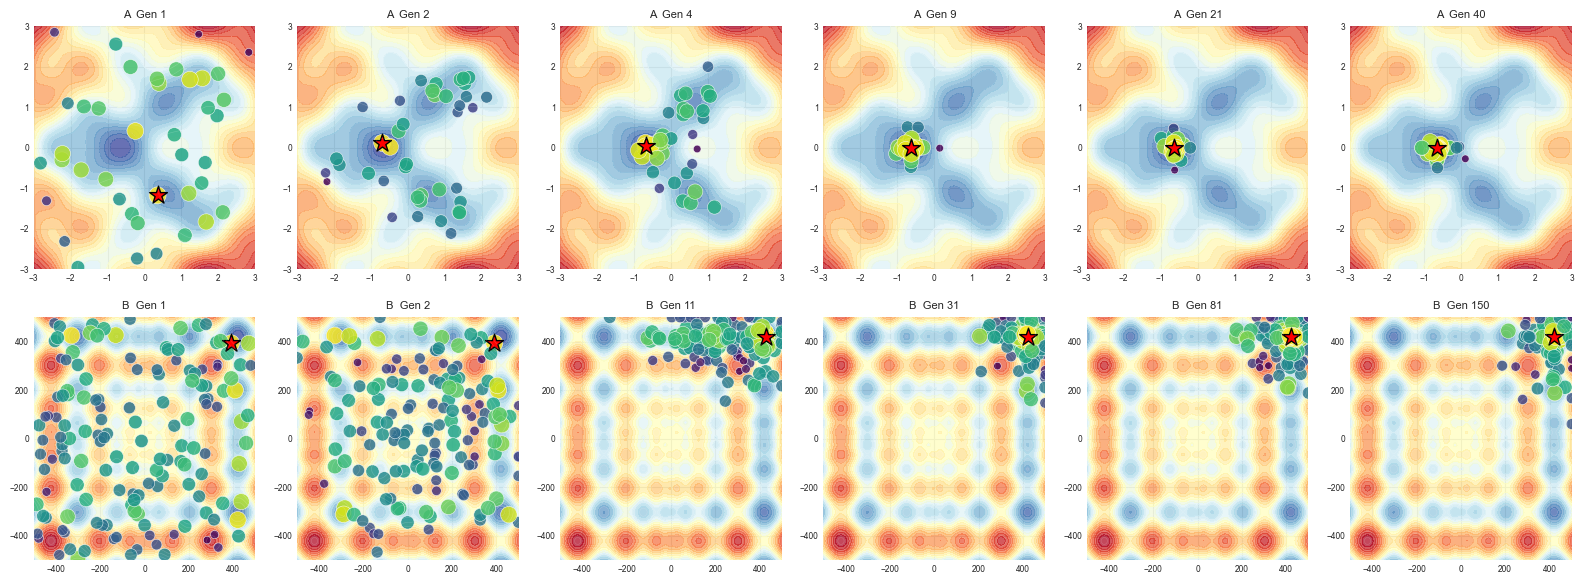

In [10]:
# ════════════════════════════════════════════════════════════════════════
# Instantáneas evolutivas sobre ambos paisajes
# ════════════════════════════════════════════════════════════════════════

def plot_snapshots(fig, row_offset, snap_gens, snapshots, GX, GY, GZ,
                   fitness_fn, xy_min, xy_max, label):
    n = len(snap_gens)
    for col, gen in enumerate(snap_gens):
        ax       = fig.add_subplot(2, n, row_offset * n + col + 1)
        pop_snap = snapshots[gen]
        fit_snap = fitness_fn(pop_snap)
        best_s   = pop_snap[np.argmax(fit_snap)]

        ax.contourf(GX, GY, GZ, levels=25, cmap='RdYlBu_r', alpha=0.75)
        ax.contour(GX, GY, GZ,  levels=12, colors='white', alpha=0.2, linewidths=0.4)

        fit_range = fit_snap.max() - fit_snap.min() + 1e-10
        sizes     = 30 + 120 * (fit_snap - fit_snap.min()) / fit_range

        ax.scatter(pop_snap[:, 0], pop_snap[:, 1],
                   s=sizes, c=fit_snap, cmap='viridis',
                   edgecolors='white', linewidth=0.4, alpha=0.85)

        ax.scatter(best_s[0], best_s[1],
                   s=180, color='red', marker='*',
                   edgecolors='black', linewidth=1)

        ax.set_title(f"{label}  Gen {gen+1}", fontsize=8)
        ax.set_xlim(xy_min, xy_max)
        ax.set_ylim(xy_min, xy_max)
        ax.tick_params(labelsize=6)

# Grillas de fondo (si no existen en memoria)
gx_A, gy_A = np.linspace(A_MIN, A_MAX, 200), np.linspace(A_MIN, A_MAX, 200)
GXA, GYA   = np.meshgrid(gx_A, gy_A)
GZA        = f_multimodal(GXA, GYA)

gx_B, gy_B = np.linspace(B_MIN, B_MAX, 200), np.linspace(B_MIN, B_MAX, 200)
GXB, GYB   = np.meshgrid(gx_B, gy_B)
GZB        = f_schwefel_2d(GXB, GYB)

fig = plt.figure(figsize=(16, 6))

plot_snapshots(fig, 0, A_SNAPS, res_A['snapshots'],
               GXA, GYA, GZA, fitness_multimodal, A_MIN, A_MAX, "A")

plot_snapshots(fig, 1, B_SNAPS, res_B['snapshots'],
               GXB, GYB, GZB, fitness_schwefel, B_MIN, B_MAX, "B")

plt.tight_layout()
plt.show()

Las instantáneas permiten observar la dinámica poblacional. El tamaño del marcador codifica fitness relativo y la estrella identifica al mejor individuo. En la función ad hoc se aprecia la rápida concentración en una cuenca. En Schwefel la población permanece dispersa durante más generaciones debido a la necesidad de exploración global antes de la explotación local.

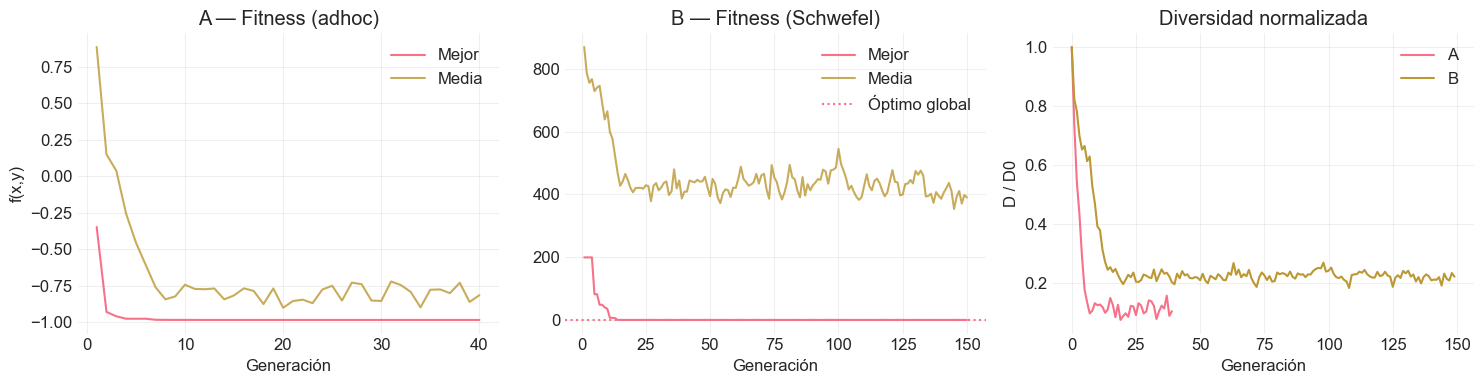

In [11]:
# ════════════════════════════════════════════════════════════════════════
# Evolución del fitness y pérdida de diversidad
# ════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Parte A — fitness
gens_A = np.arange(1, A_GENS + 1)
bA = -np.array(res_A['history_best_fit'])
mA = -np.array(res_A['history_mean_fit'])
wA = -np.array(res_A['history_worst_fit'])

axes[0].plot(gens_A, bA, label='Mejor')
axes[0].plot(gens_A, mA, label='Media', alpha=0.8)
axes[0].set_title('A — Fitness (adhoc)')
axes[0].set_xlabel('Generación')
axes[0].set_ylabel('f(x,y)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parte B — fitness
gens_B = np.arange(1, B_GENS + 1)
bB = -np.array(res_B['history_best_fit'])
mB = -np.array(res_B['history_mean_fit'])
wB = -np.array(res_B['history_worst_fit'])

axes[1].plot(gens_B, bB, label='Mejor')
axes[1].plot(gens_B, mB, label='Media', alpha=0.8)
axes[1].axhline(0, linestyle=':', label='Óptimo global')
axes[1].set_title('B — Fitness (Schwefel)')
axes[1].set_xlabel('Generación')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Diversidad normalizada
divA = np.array(res_A['history_diversity'])
divB = np.array(res_B['history_diversity'])

axes[2].plot(divA / divA[0], label='A')
axes[2].plot(divB / divB[0], label='B')
axes[2].set_title('Diversidad normalizada')
axes[2].set_xlabel('Generación')
axes[2].set_ylabel('D / D0')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Las curvas de fitness permiten observar la dinámica de explotación del algoritmo a lo largo de las generaciones. La trayectoria del **mejor fitness** muestra la capacidad del algoritmo para encontrar soluciones cada vez más profundas dentro del paisaje: descensos rápidos indican descubrimiento de cuencas prometedoras, mientras que mesetas sugieren estancamiento local. La **media poblacional** refleja el desplazamiento global de la población hacia regiones de mayor calidad, y la **distancia entre la curva del mejor y la media** funciona como un indicador de presión selectiva: cuando la brecha es grande, pocos individuos dominan la población; cuando se reduce, la población se ha concentrado en una misma cuenca.

En la función *ad hoc* se observa típicamente una caída rápida del mejor fitness seguida de una convergencia temprana, acompañada por una reducción acelerada de la diversidad normalizada. Esto indica que la población identifica pronto un valle dominante y colapsa alrededor de él, favoreciendo la explotación sobre la exploración.

En el caso de Schwefel, la mejora del fitness es más gradual y la brecha entre mejor y media persiste durante más generaciones. La **diversidad decrece más lentamente**, lo que evidencia que el algoritmo mantiene múltiples regiones activas del espacio de búsqueda antes de concentrarse en el óptimo. Este comportamiento es consistente con un paisaje engañoso, donde la exploración sostenida es necesaria para evitar mínimos locales dominantes alejados del óptimo global.

---

## 8. Métodos de selección en algoritmos evolutivos

La **selección** determina qué individuos contribuyen a la siguiente generación y controla con ello la **presión selectiva**, es decir, qué tan rápido se concentra la población en soluciones de alta calidad. Por lo tanto, el método seleccionado ejerce una influencia en la forma en que exploramos el espacio de búsqueda. 

Veamos los principales métodos de selección y cómo modifican nuestra estrategia de exploración, tomando como ejemplo la siguiente población, con los individuos ya ordenados según su evaluación de aptitud:

<p align="center">
  <img src="images/seleccion_poblacion.png" width="500">
</p>


### Selección proporcional al fitness (Ruleta)

Cada individuo se selecciona con probabilidad proporcional a su fitness.

$P(i) = \frac{f_i}{\sum_j f_j}$

<p align="center">
  <img src="images/ruleta_ejemplo.png" width="80%">
</p>


**Ventajas**
- Es un método simple y conceptualmente directo: todos los individuos en la población tienen oportunidad de ser elegidos, lo que mantiene la diversidad, pero aquellos con mayor aptitud tienen mayor probabilidad de influir en las poblaciones siguientes.  
- Mantiene la diversidad de la población, siempre y cuando los fitness en la población sean similares.

**Desventajas**
- El problema del **Superindividuo** → Convergencia Prematura: Si un individuo tiene un valor de fitness mucho mayor que el resto de la población, su "rebanada" en la ruleta será tan grande que será seleccionado casi siempre. En ese caso, la diversidad genética se pierde rápidamente, el algoritmo se estanca sin explorar a fondo el espacio de búsqueda, y puede converger a un óptimo local.
- El problema de la **Baja presión selectiva**: Si todos los individuos tienen fitness similares o si los valores son muy altos y cercanos, la diferencia de tamaño entre las "rebanadas" de la ruleta es insignificante. El algoritmo entonces se comporta como una búsqueda aleatoria, volviéndose muy lento para encontrar mejores soluciones. 


### Selección por ranking

La selección por ranking (o clasificación) es un método diseñado para superar las limitaciones de la selección proporcional (como la ruleta), enfocándose en el orden de los individuos en lugar de su valor absoluto de aptitud (fitness). Los individuos se ordenan por fitness y se asignan probabilidades según su posición, no su valor absoluto.

<p align="center">
  <img src="images/ranking_ejemplo.png" width="80%">
</p>

**Ventajas**
- Previene la convergencia prematura: Evita que unos pocos individuos muy aptos dominen las primeras generaciones.
- Mantiene la diversidad: Al no depender del valor absoluto del fitness, incluso los individuos menos aptos tienen una probabilidad de ser seleccionados, lo que ayuda a explorar mejor el espacio de búsqueda.
- Independencia de la escala: Solo importa si un individuo es "mejor" que otro, no el valor absoluto del fitness. 

**Desventajas**
- Pierde información de magnitud del fitness: no hay atractor claro a buenas regiones.
- Convergencia más lenta: Debido a que la presión de selección es menor, puede tardar más generaciones en encontrar la solución óptima.
- Costo Computacional: Requiere ordenar la población en cada generación, lo que implica mayor complejidad computacional.
 

### Selección por torneo

Se eligen $k$ individuos de la población, tomados al azar y se selecciona al candidato con mayor aptitud.

<p align="center">
  <img src="images/torneo_ejemplo.png" width="450">
</p>

A diferencia del método de ranking, el torneo no requiere ordenar a toda la población, y a diferencia de ruleta no requiere tampoco calcular la suma total de la aptitud para normalizar las probabilidades.

**Ventajas**
- Fácil de implementar
- Baja complejidad computacional: Solo se requiere elegir individuos al azar y encontrar el mejor entre ellos.
- Independencia de la escala: Como en el caso del método de ranking, solo importa quién es "mejor" en cada torneo, no su aptitud directa. 
- Control directo de presión selectiva: La exigencia de la selección se ajusta fácilmente cambiando el tamaño del torneo (el valor de $k$). Un torneo grande favorece a los más aptos que estarán repitiendo en los torneos, mientras que los torneos pequeños mantienen alta diversidad.  
- Funciona bien en paralelo, porque la selección (y el reemplazo) se realiza por grupos.  

**Desventajas**
- Presión selectiva alta si $k$ es grande: Los individuos ligeramente mejores ganan siempre, y los individuos "promedio" (que podrían tener genes útiles a largo plazo) son eliminados rápidamente. Esto hace que la población se vuelva homogénea muy pronto, provocando convergencia prematura.
- El "ruido" de la selección": Dado que la elección es probabilística, puede ocurrir que individuos mediocres resulten ganadores simplemente porque le tocó competir contra otros aún peores. Y, a la inversa, individuos excelentes pueden ser descartados si no salen elegidos en los sorteos aleatorios.


### Selección elitista

Los mejores $n$ individuos de la población actual pasan directamente a la siguiente generación, sin ser modificados por los operadores de cruce o mutación. Generalmente se combina con otro método de selección (como torneo o ranking) para el resto de la población. En realidad, el elitismo no es propiamente un mecanismo de selección completo, sino una estrategia para garantizar que las mejores soluciones encontradas no se pierdan por azar durante la reproducción.

**Ventajas**
- Garantiza monotonicidad: el mejor fitness de la población nunca empeora de una generación a otra.
- Acelera la convergencia: las soluciones de alta calidad se propagan directamente, sin depender de la lotería del cruce o la mutación.
- Bajo costo computacional: esta parte de la selección solo requiere identificar y copiar los $n$ mejores individuos.

**Desventajas**
- Riesgo de convergencia prematura: si los individuos élite son *superindividuos* dominarán demasiado temprano, la población puede quedar atrapada en un óptimo local.
- Reduce la diversidad genética: los individuos élite se replican sin variación, ocupando espacio en la población que podría usarse para explorar nuevas regiones del espacio de búsqueda.


### Selección truncada

Es una variedad del elitismo: Solo los mejores individuos en la población pueden reproducirse. Cada uno de estos individuos genera el mismo número de descendientes, independientemente de su calidad dentro del grupo seleccionado.

**Ventajas**
- Alta presión selectiva: elimina completamente a los individuos de menor rendimiento, concentrando la búsqueda en las regiones más prometedoras.
- Simple e interpretable: el umbral $n$ de individuos que pueden reproducirse es un hiperparámetro intuitivo y fácil de ajustar.
- Eficiente computacionalmente: no requiere calcular probabilidades individuales; basta con ordenar y cortar.

**Desventajas**
- Alta pérdida de diversidad: toda la fracción inferior de la población es descartada por completo, incluyendo individuos que podrían portar genes útiles a largo plazo.
- Sin diferenciación interna: dentro del grupo seleccionado, todos tienen la misma probabilidad de reproducirse sin importar qué tan superior sea uno respecto al otro, lo que desperdicia información de fitness.


### Comparación de presión selectiva

| Método        | Presión selectiva | Diversidad | Robustez al escalamiento |
|--------------|-------------------|-----------|---------------------------|
| Roulette       | Media              | Alta      | Baja                      |
| Ranking        | Media–alta         | Media     | Alta                      |
| Torneo (k pequeño) | Baja–media    | Alta      | Alta                      |
| Torneo (k grande)  | Alta          | Baja      | Alta                      |
| Elitismo       | Muy alta           | Muy baja  | Alta                      |
| Truncamiento   | Alta               | Baja      | Alta                      |

La selección controla el balance **exploración–explotación**. Una presión selectiva alta acelera convergencia pero reduce diversidad; la presión baja mantiene exploración.

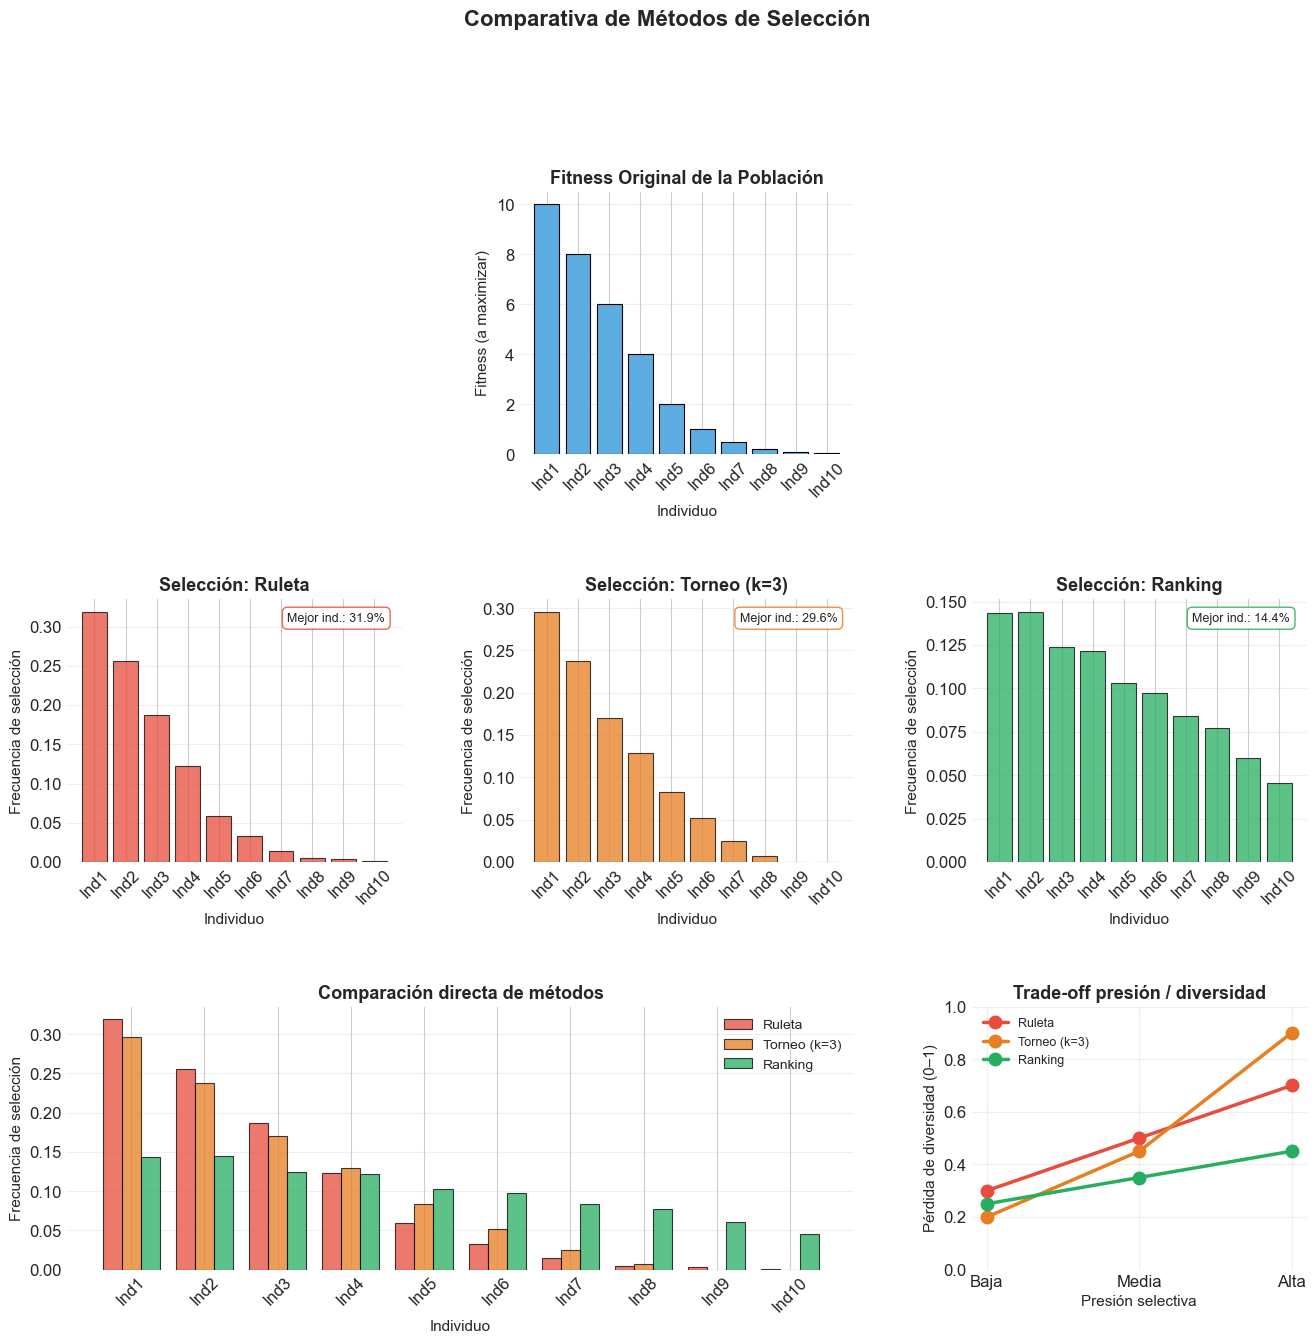


  ANÁLISIS COMPARATIVO DE MÉTODOS DE SELECCIÓN

 Método          Prob. Mejor   Diversidad  Correlación
------------------------------------------------------
 Ruleta                0.319        0.728        1.000
 Torneo (k=3)          0.296        0.762        0.995
 Ranking               0.144        0.976        0.904


In [12]:
# COMPARATIVA DE MÉTODOS DE SELECCIÓN
# ===================================

def simulacion_seleccion(fitness, metodo='ruleta', tam_poblacion=1000, k_torneo=3):
    """Simula la distribución de selección de un método (maximización)."""
    conteo = np.zeros(len(fitness))
    
    if metodo == 'ruleta':
        # Mayor fitness → mayor probabilidad
        fitness_ajustado = fitness + 1e-10
        probabilidades = fitness_ajustado / np.sum(fitness_ajustado)
        for _ in range(tam_poblacion):
            idx = np.random.choice(len(fitness), p=probabilidades)
            conteo[idx] += 1
            
    elif metodo == 'torneo':
        for _ in range(tam_poblacion):
            competidores = np.random.choice(len(fitness), k_torneo, replace=False)
            ganador = competidores[np.argmax(fitness[competidores])]
            conteo[ganador] += 1
            
    elif metodo == 'ranking':
        # Ranking para maximización: mayor fitness → mayor probabilidad
        indices_ordenados = np.argsort(-fitness)
        probabilidades = np.linspace(1.5, 0.5, len(fitness))
        probabilidades = probabilidades / np.sum(probabilidades)
        prob_por_indice = np.zeros(len(fitness))
        for i, idx in enumerate(indices_ordenados):
            prob_por_indice[idx] = probabilidades[i]
        for _ in range(tam_poblacion):
            idx = np.random.choice(len(fitness), p=prob_por_indice)
            conteo[idx] += 1
    
    return conteo / tam_poblacion

# Población de ejemplo (ahora mayor = mejor)
np.random.seed(42)
fitness_ejemplo = np.array([10, 8, 6, 4, 2, 1, 0.5, 0.2, 0.1, 0.05])
individuos = [f'Ind{i+1}' for i in range(len(fitness_ejemplo))]

# Simulaciones
metodos = ['ruleta', 'torneo', 'ranking']
colores_metodos = {'ruleta': '#E74C3C', 'torneo': '#E67E22', 'ranking': '#27AE60'}
nombres_metodos = {'ruleta': 'Ruleta', 'torneo': 'Torneo (k=3)', 'ranking': 'Ranking'}
resultados = {}

for metodo in metodos:
    resultados[metodo] = simulacion_seleccion(fitness_ejemplo, metodo=metodo, tam_poblacion=10000)

# ── LAYOUT ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.35)

ax_fitness  = fig.add_subplot(gs[0, 1])
ax_metodos  = [fig.add_subplot(gs[1, i]) for i in range(3)]
ax_comp1    = fig.add_subplot(gs[2, :2])
ax_comp2    = fig.add_subplot(gs[2, 2])

# ── Fila 1: Fitness original ───────────────────────────────────────────
ax_fitness.bar(individuos, fitness_ejemplo, color='#5DADE2', edgecolor='black', linewidth=0.8)
ax_fitness.set_xlabel('Individuo', fontsize=11)
ax_fitness.set_ylabel('Fitness (a maximizar)', fontsize=11)
ax_fitness.set_title('Fitness Original de la Población', fontsize=13, fontweight='bold')
ax_fitness.tick_params(axis='x', rotation=45)
ax_fitness.grid(True, alpha=0.3, axis='y')

# ── Fila 2: Métodos ────────────────────────────────────────────────────
for ax, metodo in zip(ax_metodos, metodos):
    color = colores_metodos[metodo]
    barras = ax.bar(individuos, resultados[metodo], color=color, edgecolor='black',
                    alpha=0.75, linewidth=0.8)
    ax.set_xlabel('Individuo', fontsize=11)
    ax.set_ylabel('Frecuencia de selección', fontsize=11)
    ax.set_title(f'Selección: {nombres_metodos[metodo]}', fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    mejor_idx = np.argmax(fitness_ejemplo)
    frecuencia_mejor = resultados[metodo][mejor_idx]
    ax.text(0.95, 0.95, f'Mejor ind.: {frecuencia_mejor:.1%}',
            transform=ax.transAxes, fontsize=9, ha='right',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor=color))

# ── Fila 3a: Comparación ───────────────────────────────────────────────
x = np.arange(len(individuos))
ancho = 0.26

for i, metodo in enumerate(metodos):
    offset = (i - 1) * ancho
    ax_comp1.bar(x + offset, resultados[metodo], width=ancho,
                 label=nombres_metodos[metodo],
                 color=colores_metodos[metodo], alpha=0.75, edgecolor='black', linewidth=0.8)

ax_comp1.set_xlabel('Individuo', fontsize=11)
ax_comp1.set_ylabel('Frecuencia de selección', fontsize=11)
ax_comp1.set_title('Comparación directa de métodos', fontsize=13, fontweight='bold')
ax_comp1.set_xticks(x)
ax_comp1.set_xticklabels(individuos, rotation=45)
ax_comp1.legend(fontsize=10)
ax_comp1.grid(True, alpha=0.3, axis='y')

# ── Fila 3b: Trade-off (ilustrativo) ───────────────────────────────────
presion   = np.array([1, 2, 3])
datos_tradeoff = {
    'ruleta':  np.array([0.30, 0.50, 0.70]),
    'torneo':  np.array([0.20, 0.45, 0.90]),
    'ranking': np.array([0.25, 0.35, 0.45]),
}

for metodo in metodos:
    ax_comp2.plot(presion, datos_tradeoff[metodo], 'o-', linewidth=2.5, markersize=9,
                  color=colores_metodos[metodo], label=nombres_metodos[metodo])

ax_comp2.set_xlabel('Presión selectiva', fontsize=11)
ax_comp2.set_ylabel('Pérdida de diversidad (0–1)', fontsize=11)
ax_comp2.set_title('Trade-off presión / diversidad', fontsize=13, fontweight='bold')
ax_comp2.legend(fontsize=9)
ax_comp2.grid(True, alpha=0.3)
ax_comp2.set_xticks(presion)
ax_comp2.set_xticklabels(['Baja', 'Media', 'Alta'])
ax_comp2.set_ylim(0, 1)

plt.suptitle('Comparativa de Métodos de Selección', fontsize=16, fontweight='bold', y=1.01)
plt.show()

# ── ANÁLISIS CUANTITATIVO ──────────────────────────────────────────────
def calcular_metricas(frecuencias, fitness):
    mejor_idx = np.argmax(fitness)
    prob_mejor = frecuencias[mejor_idx]
    entropia = -np.sum(frecuencias * np.log(frecuencias + 1e-10))
    diversidad_normalizada = entropia / np.log(len(fitness))
    correlacion = np.corrcoef(fitness, frecuencias)[0, 1]
    return {'prob_mejor': prob_mejor, 'diversidad': diversidad_normalizada, 'correlacion': correlacion}

print("\n" + "="*65)
print("  ANÁLISIS COMPARATIVO DE MÉTODOS DE SELECCIÓN")
print("="*65)
print(f"\n {'Método':<14} {'Prob. Mejor':>12} {'Diversidad':>12} {'Correlación':>12}")
print("-"*54)
for metodo in metodos:
    m = calcular_metricas(resultados[metodo], fitness_ejemplo)
    print(f" {nombres_metodos[metodo]:<14} {m['prob_mejor']:>12.3f} {m['diversidad']:>12.3f} {m['correlacion']:>12.3f}")
print("="*65)

Las gráficas anteriores ilustran cómo distribuye la presión selectiva cada método de selección considerado sobre una población de 10 individuos con fitness conocido.

La fila 1 muestra los valores de fitness de cada individuo, como referencia.

En las gráficas de la fila 2, se muestra la distribución de la selección de los individuos para cada método: Cada barra indica con qué frecuencia fue seleccionado cada individuo a lo largo de 10,000 sorteos. El porcentaje en la tarjeta superior indica la frecuencia del mejor individuo, lo que permite medir la **concentración** de la selección.

- **Ruleta:** La probabilidad es proporcional al fitness invertido. Al haber grandes diferencias entre individuos, el mejor concentra una fracción muy alta de selecciones. La distribución cae rápidamente hacia los individuos menos aptos.
- **Torneo (k=3):** En cada torneo se eligen 3 individuos al azar y gana el mejor. Genera una presión selectiva alta pero más *suave* que la ruleta en poblaciones heterogéneas, ya que el resultado depende de con quién compita cada individuo.
- **Ranking:** Asigna probabilidades según la posición ordinal, ignorando el valor absoluto del fitness. Esto produce una distribución más *uniforme* y gradual, reduciendo el dominio del mejor individuo y favoreciendo la exploración.

En la fila 3 se presentan dos gráficas comparativas globales:
- La gráfica *Comparación directa* permite ver rápidamente qué método incluye más a los individuos de baja aptitud (alta exploración) y cuál concentra más la selección en los mejores (alta explotación).
- La gráfica *Balance presión/diversidad* muestra de forma esquemática cómo varía la pérdida de diversidad a medida que aumenta la presión selectiva en cada método. El ranking ofrece la curva más plana, lo que lo hace más robusto frente a cambios de escala del fitness. El torneo, en cambio, puede ser muy agresivo con valores de $k$ altos.

### Métricas resumen

La tabla impresa reporta tres métricas para cada método:

| Métrica | Descripción |
|---|---|
| **Prob. Mejor** | Frecuencia con la que fue seleccionado el mejor individuo. Valores altos indican mayor presión selectiva. |
| **Diversidad** | Desviación etándar normalizada de la distribución de selección. Valores cercanos a 1 indican selección más uniforme. |
| **Correlación** | Correlación entre el fitness normalizado y la frecuencia de selección. Valores altos indican que el método es más fiel a la calidad de los individuos. |

El teorema No free Lunch aplica, por supuesto, también en este caso: no existe un método universalmente mejor. La elección del método de selección a utiliar depende del problema: si se teme la convergencia prematura, conviene priorizar diversidad (ranking o torneo con $k$ pequeño); si se quiere acelerar la explotación en un espacio bien explorado, mayor presión selectiva (ruleta o torneo con $k$ grande) puede ser más efectiva.

---

## 9. Operadores de Cruza en Algoritmos Evolutivos

Una vez seleccionados los individuos que se reproducirán, el **operador de cruza** (o recombinación) combina el material genético de dos o más padres para generar descendientes. La idea central es que, si dos individuos son buenos, combinar sus características puede producir un hijo aún mejor.

Los operadores difieren principalmente en **qué tan grandes son los bloques de genes que se intercambian** y en **si permiten explorar fuera del rango definido por los padres**.


### Operadores para representaciones discretas o binarias

Estos operadores intercambian segmentos completos del cromosoma entre los dos padres.

**Cruza en un punto:** Se elige aleatoriamente una posición $p$ en el cromosoma. El hijo hereda los genes $[1, p]$ del Padre 1 y los genes $[p+1, n]$ del Padre 2. Es el operador más simple, y tiende a preservar **bloques de genes contiguos** (también llamados *building blocks*), lo que puede ser útil si los genes cercanos están correlacionados.

**Cruza en dos puntos:** Se eligen dos posiciones $p_1 < p_2$. El hijo hereda el segmento central $[p_1, p_2]$ de un padre y los extremos del otro. Al romper el cromosoma en más regiones, aumenta la diversidad genética sin perder del todo la noción de bloques.

**Cruza uniforme:** Para cada gen, se decide independientemente (con probabilidad $0.5$) de qué padre se hereda. No hay bloques: cada gen se trata de forma individual. Esto maximiza la recombinación, pero puede **romper correlaciones entre genes adyacentes**, lo que lo hace menos eficiente en problemas con alta *epistasis* (cuando un gen enmascara o inhibe la expresión de otro).


### Operadores para representaciones continuas (valores reales)

Cuando los genes son números reales, los operadores discretos no son naturales. Los siguientes están diseñados para producir hijos con valores *interpolados* o *extrapolados* respecto a los padres.

**Cruza aritmética:** El hijo se genera como una combinación convexa de los dos padres:

$$\mathbf{h} = \alpha \, \mathbf{p}_1 + (1-\alpha) \, \mathbf{p}_2, \quad \alpha \in [0, 1]$$

El resultado siempre cae **dentro del segmento** que une a los dos padres. Es suave y estable, ideal para refinar soluciones, pero limita la exploración.

**BLX-$\alpha$ (Blend Crossover):** Extiende la cruza aritmética permitiendo que el hijo caiga **fuera del intervalo** entre los padres. Para cada gen $i$, se define un intervalo extendido:

$$\left[\min(p_{1i}, p_{2i}) - \alpha \cdot I_i,\; \max(p_{1i}, p_{2i}) + \alpha \cdot I_i\right]$$

donde $I_i = |p_{1i} - p_{2i}|$ y $\alpha$ controla cuánto se extiende el rango. Esto aporta capacidad de exploración sin alejarse demasiado de los padres.

Una vez definido ese rango extendido para cada gen, el hijo se genera seleccionando un valor aleatorio con distribución uniforme dentro de dicho intervalo.

**SBX (Simulated Binary Crossover):** Este operador fue diseñado para imitar la mecánica de la cruza de un punto de los algoritmos genéticos binarios, pero operando directamente en el **espacio continuo**. Es el operador por defecto en algoritmos de referencia como **NSGA-II** (*Algoritmo Genético de Ordenamiento No Dominado II*).

El operador genera dos hijos ($h_1, h_2$) a partir de dos padres ($p_1, p_2$) utilizando un factor de expansión probabilístico llamado $\beta$. La posición de los hijos se calcula como:

$$h_1 = \frac{1}{2}[(1 + \beta)p_1 + (1 - \beta)p_2]$$
$$h_2 = \frac{1}{2}[(1 - \beta)p_1 + (1 + \beta)p_2]$$

Donde el valor de $\beta$ se obtiene a partir de una variable aleatoria $u \in [0, 1]$ y un **índice de distribución $\eta$**.
El parámetro $\eta$ (eta) es un número real positivo que controla qué tan cerca de los padres se encontrarán los hijos:

*   **$\eta$ pequeño (p. ej., 10):** Produce una distribución de probabilidad "plana". Los hijos tienen mayor probabilidad de ser muy distintos a los padres, fomentando la **exploración**.
*   **$\eta$ grande (p. ej., 20 o más):** La probabilidad se concentra fuertemente alrededor de los padres. Los hijos serán muy similares a ellos, fomentando la **explotación** (ajuste fino).

<p align="center">
  <img src="images/sbx.png" width="450">
</p>

> **Nota:** Una característica clave de SBX es que preserva el "orden de magnitud" de los genes y posee una propiedad de auto-adaptación: si los padres están lejos, la búsqueda es amplia; si están cerca, la búsqueda se vuelve local automáticamente.



PADRES DE EJEMPLO
Padre 1: [3.75 9.51 7.32 5.99 1.56 1.56 0.58 8.66 6.01 7.08]
Padre 2: [0.21 9.7  8.32 2.12 1.82 1.83 3.04 5.25 4.32 2.91]



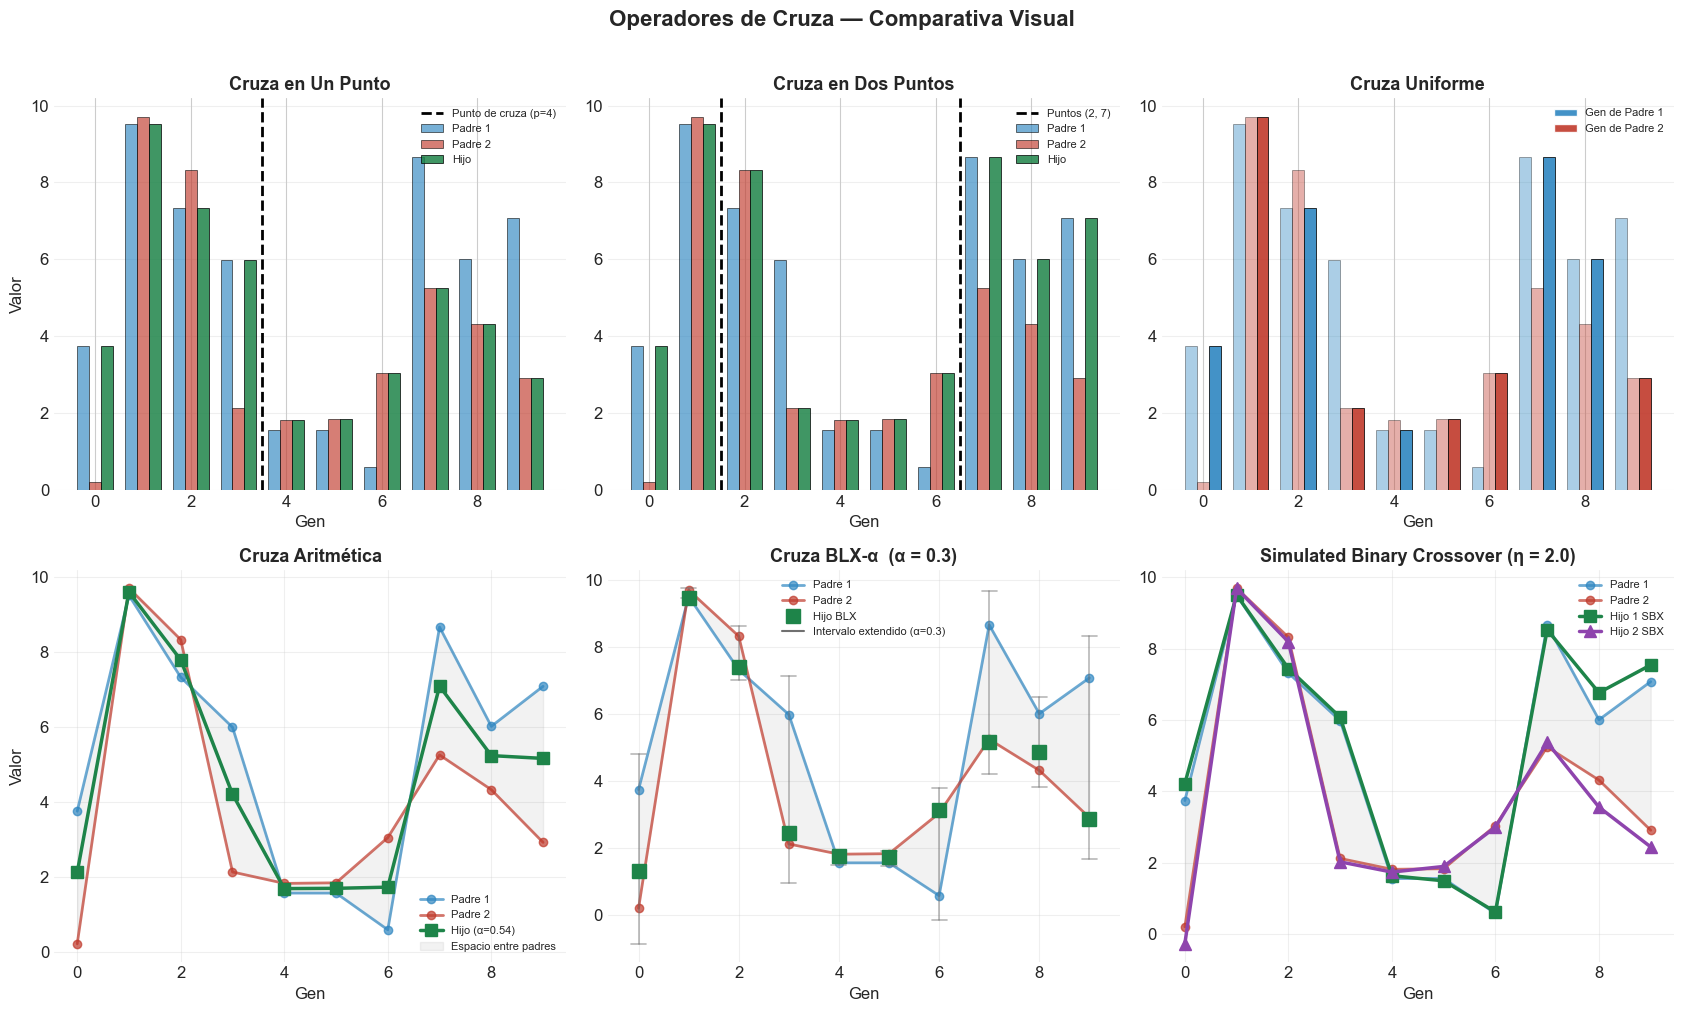


  CARACTERÍSTICAS DE LOS OPERADORES DE CRUZA
Operador       Complejidad   Exploración   Explotación   Uso típico                 Ventaja clave
-----------------------------------------------------------------------------------------------
1 punto        Baja          Media         Alta          Binaria / discreta         Preserva bloques de genes contiguos
2 puntos       Baja          Media-alta    Media         Binaria / discreta         Más diversidad que un punto
Uniforme       Baja          Alta          Baja          Sin epistasis fuerte       Máxima recombinación gen a gen
Aritmética     Media         Baja          Alta          Optimización continua      Hijos siempre entre los padres
BLX-α          Media         Alta          Media         Continua multimodal        Explora fuera del rango parental
SBX            Alta          Media         Alta          Optimización continua      Distribución controlada por η


In [13]:
# VISUALIZACIÓN DE OPERADORES DE CRUZA
# =====================================

from matplotlib.patches import Patch

def visualizar_cruza(padre1, padre2, dimensiones=10):
    """Visualiza diferentes operadores de cruza."""

    colores = {'p1': '#2E86C1', 'p2': '#C0392B', 'h': '#1E8449',
               'h2': '#8E44AD', 'rango': '#707070'}

    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    fig.suptitle('Operadores de Cruza — Comparativa Visual',
                 fontsize=16, fontweight='bold', y=1.01)

    x = np.arange(dimensiones)

    # ── 1. CRUZA EN UN PUNTO ──────────────────────────────────────────────
    ax = axes[0, 0]
    punto = np.random.randint(2, dimensiones - 2)
    hijo_1p = np.concatenate([padre1[:punto], padre2[punto:]])

    ax.bar(x - 0.25, padre1, width=0.25, alpha=0.65, color=colores['p1'], label='Padre 1', edgecolor='black', linewidth=0.6)
    ax.bar(x,        padre2, width=0.25, alpha=0.65, color=colores['p2'], label='Padre 2', edgecolor='black', linewidth=0.6)
    ax.bar(x + 0.25, hijo_1p,width=0.25, alpha=0.85, color=colores['h'],  label='Hijo',    edgecolor='black', linewidth=0.6)
    ax.axvline(punto - 0.5, color='black', linestyle='--', linewidth=2, label=f'Punto de cruza (p={punto})')

    ax.set_title('Cruza en Un Punto', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen'); ax.set_ylabel('Valor')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

    # ── 2. CRUZA EN DOS PUNTOS ────────────────────────────────────────────
    ax = axes[0, 1]
    p1, p2 = sorted(np.random.choice(range(2, dimensiones - 1), 2, replace=False))
    hijo_2p = np.concatenate([padre1[:p1], padre2[p1:p2], padre1[p2:]])

    ax.bar(x - 0.25, padre1,  width=0.25, alpha=0.65, color=colores['p1'], label='Padre 1', edgecolor='black', linewidth=0.6)
    ax.bar(x,        padre2,  width=0.25, alpha=0.65, color=colores['p2'], label='Padre 2', edgecolor='black', linewidth=0.6)
    ax.bar(x + 0.25, hijo_2p, width=0.25, alpha=0.85, color=colores['h'],  label='Hijo',    edgecolor='black', linewidth=0.6)
    ax.axvline(p1 - 0.5, color='black', linestyle='--', linewidth=2, label=f'Puntos ({p1}, {p2})')
    ax.axvline(p2 - 0.5, color='black', linestyle='--', linewidth=2)

    ax.set_title('Cruza en Dos Puntos', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

    # ── 3. CRUZA UNIFORME ─────────────────────────────────────────────────
    ax = axes[0, 2]
    mascara = np.random.random(dimensiones) < 0.5
    hijo_unif = np.where(mascara, padre1, padre2)

    ax.bar(x - 0.25, padre1,    width=0.25, alpha=0.4, color=colores['p1'], edgecolor='black', linewidth=0.6)
    ax.bar(x,        padre2,    width=0.25, alpha=0.4, color=colores['p2'], edgecolor='black', linewidth=0.6)
    bar_colors = [colores['p1'] if m else colores['p2'] for m in mascara]
    for i in range(dimensiones):
        ax.bar(x[i] + 0.25, hijo_unif[i], width=0.25, color=bar_colors[i], alpha=0.9, edgecolor='black', linewidth=0.6)

    legend_elems = [Patch(facecolor=colores['p1'], alpha=0.9, label='Gen de Padre 1'),
                    Patch(facecolor=colores['p2'], alpha=0.9, label='Gen de Padre 2')]
    ax.legend(handles=legend_elems, fontsize=8)
    ax.set_title('Cruza Uniforme', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen'); ax.grid(True, alpha=0.3, axis='y')

    # ── 4. CRUZA ARITMÉTICA ───────────────────────────────────────────────
    ax = axes[1, 0]
    alpha_arit = np.random.uniform(0.2, 0.8)
    hijo_arit = alpha_arit * padre1 + (1 - alpha_arit) * padre2

    ax.plot(x, padre1,    'o-', color=colores['p1'], lw=2,   ms=6,  label='Padre 1', alpha=0.7)
    ax.plot(x, padre2,    'o-', color=colores['p2'], lw=2,   ms=6,  label='Padre 2', alpha=0.7)
    ax.plot(x, hijo_arit, 's-', color=colores['h'],  lw=2.5, ms=8,  label=f'Hijo (α={alpha_arit:.2f})')
    ax.fill_between(x, padre1, padre2, alpha=0.1, color='gray', label='Espacio entre padres')

    ax.set_title('Cruza Aritmética', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen'); ax.set_ylabel('Valor')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── 5. BLX-α ──────────────────────────────────────────────────────────
    ax = axes[1, 1]
    alpha_blx = 0.3
    c_min = np.minimum(padre1, padre2)
    c_max = np.maximum(padre1, padre2)
    I = c_max - c_min
    lower = c_min - alpha_blx * I
    upper = c_max + alpha_blx * I
    hijo_blx = np.random.uniform(lower, upper)

    ax.plot(x, padre1, 'o-', color=colores['p1'], lw=2, ms=6, label='Padre 1', alpha=0.7)
    ax.plot(x, padre2, 'o-', color=colores['p2'], lw=2, ms=6, label='Padre 2', alpha=0.7)
    for i in x:
        ax.plot([i, i], [lower[i], upper[i]], '-', color=colores['rango'], lw=1.2, alpha=0.5)
        ax.plot([i-0.15, i+0.15], [lower[i], lower[i]], '-', color=colores['rango'], lw=1.2, alpha=0.5)
        ax.plot([i-0.15, i+0.15], [upper[i], upper[i]], '-', color=colores['rango'], lw=1.2, alpha=0.5)
    ax.plot(x, hijo_blx, 's', color=colores['h'], ms=10, label='Hijo BLX', zorder=5)
    ax.fill_between(x, padre1, padre2, alpha=0.1, color='gray')

    from matplotlib.lines import Line2D
    legend_extra = [Line2D([0], [0], color=colores['rango'], lw=1.5, label=f'Intervalo extendido (α={alpha_blx})')]
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles + legend_extra, fontsize=8)
    ax.set_title(f'Cruza BLX-α  (α = {alpha_blx})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen'); ax.grid(True, alpha=0.3)

    # ── 6. SBX ────────────────────────────────────────────────────────────
    ax = axes[1, 2]
    eta = 2.0

    def sbx_beta(u, eta):
        return (2*u)**(1/(eta+1)) if u <= 0.5 else (1/(2*(1-u)))**(1/(eta+1))

    hijo1_sbx = np.zeros(dimensiones)
    hijo2_sbx = np.zeros(dimensiones)
    for i in range(dimensiones):
        u = np.random.random()
        beta = sbx_beta(u, eta)
        hijo1_sbx[i] = 0.5 * ((1 + beta)*padre1[i] + (1 - beta)*padre2[i])
        hijo2_sbx[i] = 0.5 * ((1 - beta)*padre1[i] + (1 + beta)*padre2[i])

    ax.plot(x, padre1,    'o-', color=colores['p1'],  lw=2,   ms=6,  label='Padre 1',  alpha=0.7)
    ax.plot(x, padre2,    'o-', color=colores['p2'],  lw=2,   ms=6,  label='Padre 2',  alpha=0.7)
    ax.plot(x, hijo1_sbx, 's-', color=colores['h'],   lw=2.5, ms=8,  label='Hijo 1 SBX')
    ax.plot(x, hijo2_sbx, '^-', color=colores['h2'],  lw=2.5, ms=8,  label='Hijo 2 SBX')
    ax.fill_between(x, padre1, padre2, alpha=0.1, color='gray')

    ax.set_title(f'Simulated Binary Crossover (η = {eta})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        '1_punto':    hijo_1p,
        '2_puntos':   hijo_2p,
        'uniforme':   hijo_unif,
        'aritmetica': hijo_arit,
        'blx':        hijo_blx,
        'sbx':        (hijo1_sbx, hijo2_sbx)
    }

# ── Padres de ejemplo ────────────────────────────────────────────────────
np.random.seed(42)
dim = 10
padre1 = np.random.uniform(0, 10, dim)
padre2 = np.random.uniform(0, 10, dim)

print("PADRES DE EJEMPLO")
print(f"Padre 1: {padre1.round(2)}")
print(f"Padre 2: {padre2.round(2)}\n")

hijos = visualizar_cruza(padre1, padre2, dimensiones=dim)

# ── Tabla comparativa ────────────────────────────────────────────────────
print("\n" + "="*95)
print("  CARACTERÍSTICAS DE LOS OPERADORES DE CRUZA")
print("="*95)

caracteristicas = {
    "1 punto":       ("Baja",  "Media",      "Alta",  "Binaria / discreta",       "Preserva bloques de genes contiguos"),
    "2 puntos":      ("Baja",  "Media-alta", "Media", "Binaria / discreta",       "Más diversidad que un punto"),
    "Uniforme":      ("Baja",  "Alta",       "Baja",  "Sin epistasis fuerte",     "Máxima recombinación gen a gen"),
    "Aritmética":    ("Media", "Baja",       "Alta",  "Optimización continua",    "Hijos siempre entre los padres"),
    "BLX-α":         ("Media", "Alta",       "Media", "Continua multimodal",      "Explora fuera del rango parental"),
    "SBX":           ("Alta",  "Media",      "Alta",  "Optimización continua",    "Distribución controlada por η"),
}

header = f"{'Operador':<14} {'Complejidad':<13} {'Exploración':<13} {'Explotación':<13} {'Uso típico':<26} {'Ventaja clave'}"
print(header)
print("-"*95)
for nombre, vals in caracteristicas.items():
    print(f"{nombre:<14} {vals[0]:<13} {vals[1]:<13} {vals[2]:<13} {vals[3]:<26} {vals[4]}")
print("="*95)

Las gráficas anteriores muestran cómo cada operador transforma el material genético de los dos padres para producir uno o dos hijos. La fila superior agrupa los **operadores discretos** y la inferior los **operadores para valores reales**.

Los tres primeros operadores comparten la misma lógica: cada gen del hijo proviene *íntegramente* de uno de los dos padres, sin interpolación. La diferencia está en el **tamaño de los bloques** que se intercambian:

- **Cruza en un punto:** El hijo es literalmente la mitad izquierda de un padre pegada con la mitad derecha del otro. La línea discontinua muestra el punto de corte elegido al azar. Es el operador que más preserva la estructura interna del cromosoma.

- **Cruza en dos puntos:** El segmento central proviene de un padre y los extremos del otro. Al haber dos puntos de corte, se reduce la probabilidad de que genes distantes siempre viajen juntos (*linkage*), lo que incrementa la diversidad sin sacrificar del todo los bloques.

- **Cruza uniforme:** Cada barra del hijo está coloreada según su padre de origen (azul = Padre 1, rojo = Padre 2). El patrón aleatorio refleja que **no hay bloques**: cada gen se decide de forma independiente. Esto produce la mayor recombinación posible, lo que es ventajoso cuando los genes no tienen correlaciones fuertes entre sí.

Los operadores continuos producen hijos con valores que son **mezclas numéricas** de los padres, no segmentos copiados.

- **Cruza aritmética:** La línea del hijo corre entre las líneas de los dos padres, sin salir jamás del área sombreada. El parámetro $\alpha$ determina qué tan cerca queda del Padre 1 ($\alpha=1$) o del Padre 2 ($\alpha=0$). Es el operador más conservador de los reales: nunca genera valores fuera del rango observado en la población.

- **BLX-α:** Las líneas verticales muestran el **intervalo extendido** disponible para cada gen. Los marcadores cuadrados (hijo) pueden caer *fuera* del rango entre los padres, lo que le da al operador capacidad de exploración. Cuanto mayor sea $\alpha$, más se extiende ese intervalo.

- **SBX:** Es el único operador que produce **dos hijos simultáneamente** (verde y morado), los cuales quedan *simétricamente distribuidos* respecto a los padres. Esto es análogo a lo que ocurre en la cruza en un punto: si un hijo hereda "más" de un padre en un gen, el otro hijo compensa heredando "más" del otro padre en ese mismo gen. El parámetro $\eta$ controla la concentración de esa distribución: con $\eta=2$ (valor usado aquí) los hijos tienden a quedarse relativamente cerca de los padres.


### Guía rápida de selección del operador

| Situación | Operador recomendado |
|---|---|
| Cromosoma binario o de permutaciones | 1 punto o 2 puntos |
| Genes sin correlaciones fuertes | Uniforme |
| Refinamiento fino en espacio continuo | Aritmética |
| Exploración en espacio continuo multimodal | BLX-α |
| Algoritmos multiobjetivo (NSGA-II, etc.) | SBX |

> En la práctica, **SBX y BLX-α** son los más utilizados en optimización continua por su buen balance entre exploración y explotación. Para problemas discretos, la **cruza en dos puntos** suele ser el punto de partida más robusto.

---

## 10. Operadores de mutación en algoritmos evolutivos

Mientras la cruza recombina material genético ya existente en la población, la **mutación** introduce cambios aleatorios en un individuo, generando material genético genuinamente nuevo. Este es su rol fundamental: sin mutación, el algoritmo solo puede explorar combinaciones del material genético presente en la población inicial y puede quedar atrapado en óptimos locales.

La mutación actúa gen a gen con una **probabilidad de mutación** $p_m$ (típicamente baja, entre 0.001 y 0.1 por gen), lo que garantiza que los cambios sean perturbaciones puntuales y no destruyan por completo las soluciones buenas ya localizadas.


### Operadores para representaciones discretas o binarias

**Mutación binaria (bit flip):** Para cromosomas binarios, cada bit se invierte ($0 \to 1$ o $1 \to 0$) con probabilidad $p_m$. Es el operador más simple y es análogo a los errores de copia en la replicación del ADN. La tasa $p_m$ controla directamente cuántos bits cambian en promedio por individuo.

**Mutación por intercambio (para permutaciones):** En problemas donde el cromosoma es una permutación (como en TSP), la mutación debe preservar la integridad del individuo. Asignar valores aleatorios crearía duplicados o faltantes, lo que violaría las restricciones del problema.  En su lugar, se **eligen dos posiciones al azar y se intercambian sus valores**. Existen variantes más potentes como la mutación por inversión (que revierte el orden de un segmento, inspirada en el operador 2-opt) y la mutación por inserción o desplazamiento (que mueve un segmento completo a una posición distinta).



### Operadores para representaciones continuas

**Mutación gaussiana:** A cada gen seleccionado (de acuerdo a $p_m$) se le suma un ruido con distribución normal:

$$x_i' = x_i + \mathcal{N}(0, \sigma)$$

El parámetro $\sigma$ controla la magnitud de la perturbación. Un $\sigma$ grande produce cambios grandes (exploración), uno pequeño produce cambios sutiles (explotación). Es el operador continuo más utilizado por su naturaleza suave y bien fundamentada.

**Mutación uniforme:** El gen mutado toma un valor completamente aleatorio dentro del rango permitido $[x_{min}, x_{max}]$, sin relación con el valor anterior. Produce cambios drásticos y es útil para escapar de óptimos locales profundos, aunque puede destruir buenas soluciones si se aplica con demasiada frecuencia.


### Operadores adaptativos

**Mutación no uniforme (decreciente):** La probabilidad $p_m$ y/o la magnitud $\sigma$ se reducen a lo largo de las generaciones, siguiendo por ejemplo una ley lineal o exponencial. Esto permite **alta exploración al inicio** (cuando aún no sabemos dónde están las buenas regiones) y **alta explotación al final** (cuando ya queremos refinar la mejor solución encontrada). Es una analogía directa al *enfriamiento* en Recocido simulado.

**Mutación auto-adaptativa (Estrategias Evolutivas):** En lugar de fijar $\sigma$ externamente, cada individuo **lleva su propio vector de sigmas** como parte de su cromosoma. Los sigmas también evolucionan: primero se mutan ellos mismos, y luego se usan para mutar los genes del individuo:

$$\sigma_i' = \sigma_i \cdot e^{\tau \cdot \mathcal{N}(0,1)}, \qquad x_i' = x_i + \sigma_i' \cdot \mathcal{N}(0,1)$$

Esto permite que el algoritmo **aprenda por sí solo** la magnitud de mutación óptima para cada gen y en cada etapa de la evolución, eliminando la necesidad de ajustar $\sigma$ manualmente.

> Una regla práctica clásica es la **regla del 1/5** (Rechenberg, 1973): la probabilidad de que una mutación mejore la solución debería ser aproximadamente 1/5. Si la tasa de éxito es mayor, se aumenta $\sigma$; si es menor, se reduce. Este principio es la base de los métodos auto-adaptativos modernos.

INDIVIDUO DE EJEMPLO
Original: [3.75 9.51 7.32 5.99 1.56 1.56 0.58 8.66 6.01 7.08 0.21 9.7  8.32 2.12
 1.82 1.83 3.04 5.25 4.32 2.91]



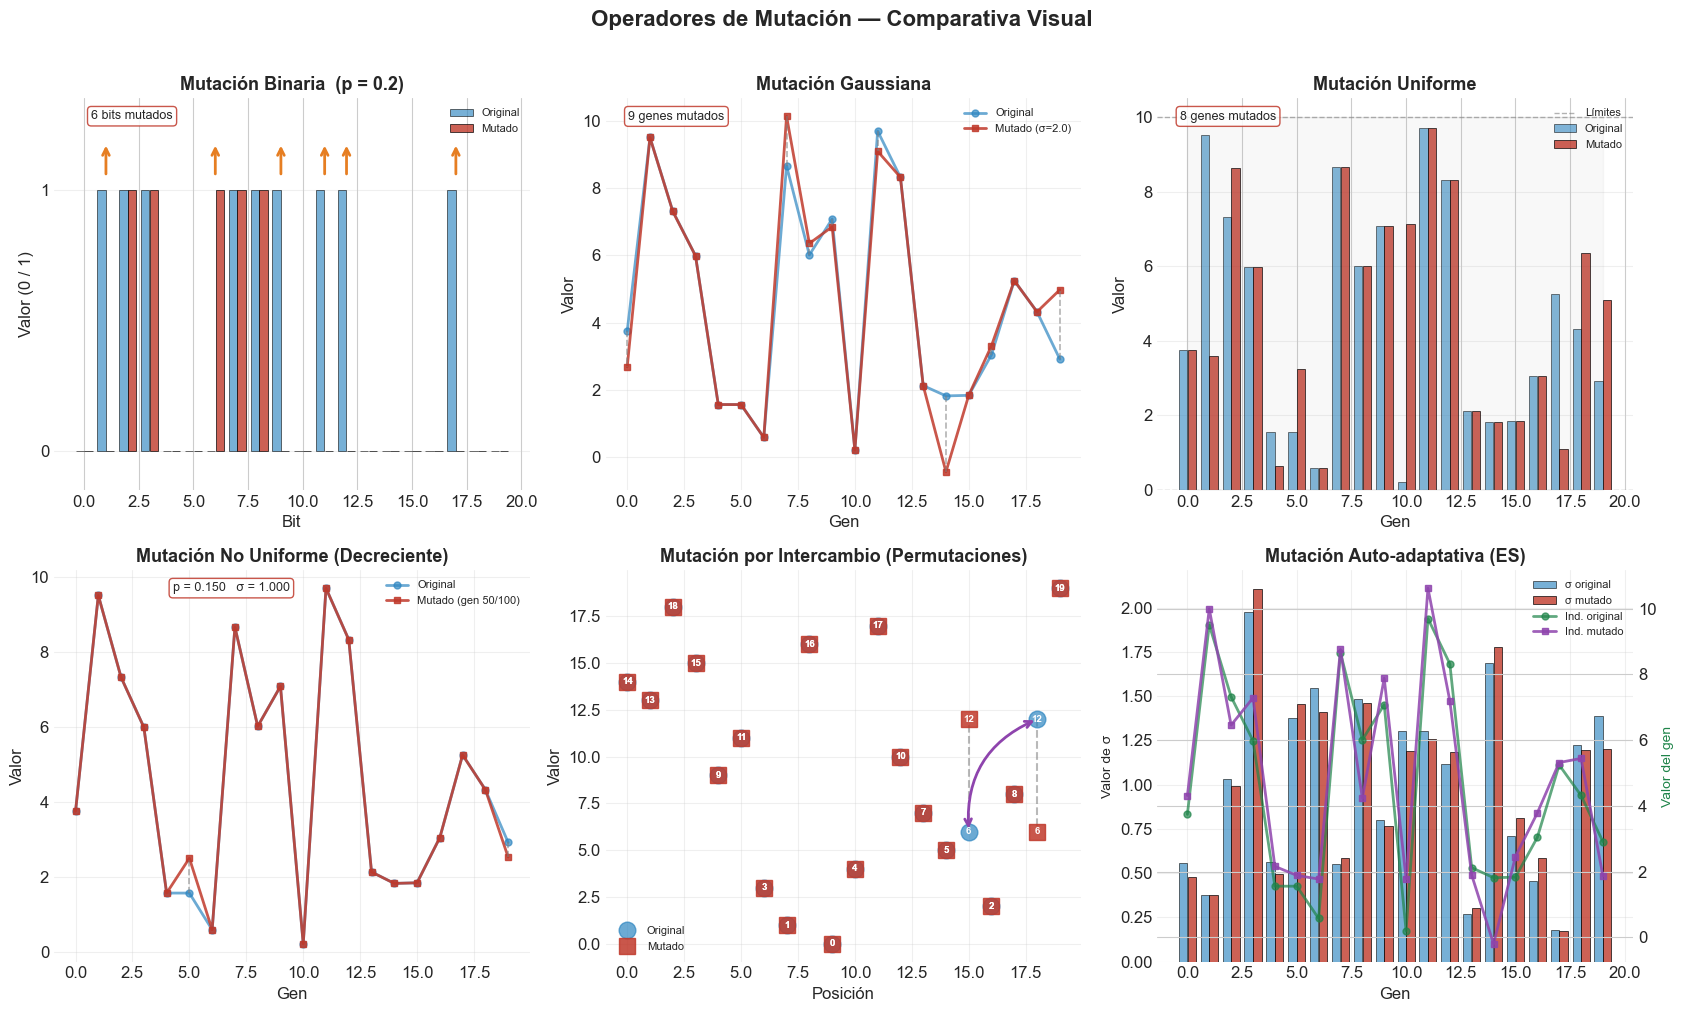

  IMPACTO DE CADA OPERADOR DE MUTACIÓN
Operador               Distancia L2  % Genes modificados
----------------------------------------------------------
binaria                      23.382               100.0%
gaussiana                     3.646                45.0%
uniforme                     10.713                40.0%
no_uniforme                   1.010                10.0%
intercambio                  33.907               100.0%
auto_adaptativa               4.553               100.0%


In [14]:
# VISUALIZACIÓN DE OPERADORES DE MUTACIÓN
# ========================================

from matplotlib.patches import Patch

def visualizar_mutaciones(individuo_original, dimensiones=20):
    """Visualiza diferentes operadores de mutación."""

    colores = {'orig': '#2E86C1', 'mut': '#C0392B',
               'sigma_orig': '#2E86C1', 'sigma_mut': '#C0392B',
               'ind_orig': '#1E8449', 'ind_mut': '#8E44AD'}

    fig, axes = plt.subplots(2, 3, figsize=(17, 10))
    fig.suptitle('Operadores de Mutación — Comparativa Visual',
                 fontsize=16, fontweight='bold', y=1.01)

    x = np.arange(dimensiones)

    # ── 1. MUTACIÓN BINARIA ───────────────────────────────────────────────
    ax = axes[0, 0]
    individuo_bin = (individuo_original > 5).astype(int)
    individuo_mut_bin = individuo_bin.copy()
    prob_mut = 0.2
    for i in range(dimensiones):
        if np.random.random() < prob_mut:
            individuo_mut_bin[i] = 1 - individuo_mut_bin[i]
    

    ax.bar(x - 0.2, individuo_bin,     width=0.38, alpha=0.65, color=colores['orig'],
           label='Original', edgecolor='black', linewidth=0.6)
    ax.bar(x + 0.2, individuo_mut_bin, width=0.38, alpha=0.80, color=colores['mut'],
           label='Mutado',   edgecolor='black', linewidth=0.6)

    bits_mutados = np.where(individuo_bin != individuo_mut_bin)[0]
    for bit in bits_mutados:
        ax.annotate('', xy=(bit, max(individuo_bin[bit], individuo_mut_bin[bit]) + 0.18),
                    xytext=(bit, max(individuo_bin[bit], individuo_mut_bin[bit]) + 0.05),
                    arrowprops=dict(arrowstyle='->', color='#E67E22', lw=2))
        
    ax.set_title(f'Mutación Binaria  (p = {prob_mut})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Bit'); ax.set_ylabel('Valor (0 / 1)')
    ax.set_yticks([0, 1]); ax.set_ylim(-0.15, 1.35)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
    ax.text(0.25, 0.97, f'{len(bits_mutados)} bits mutados', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85,
                      edgecolor=colores['mut']))

    # ── 2. MUTACIÓN GAUSSIANA ─────────────────────────────────────────────
    ax = axes[0, 1]
    sigma = 2.0
    prob_gauss = 0.3
    individuo_mut_gauss = individuo_original.copy()
    genes_gauss = []
    for i in range(dimensiones):
        if np.random.random() < prob_gauss:
            individuo_mut_gauss[i] += np.random.normal(0, sigma)
            genes_gauss.append(i)

    ax.plot(x, individuo_original,  'o-', color=colores['orig'], lw=2, ms=5,
            label='Original', alpha=0.7)
    ax.plot(x, individuo_mut_gauss, 's-', color=colores['mut'],  lw=2, ms=5,
            label=f'Mutado (σ={sigma})', alpha=0.85)
    for i in genes_gauss:
        ax.plot([i, i], [individuo_original[i], individuo_mut_gauss[i]],
                '--', color='gray', lw=1.2, alpha=0.6)

    ax.set_title('Mutación Gaussiana', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen'); ax.set_ylabel('Valor')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.text(0.25, 0.97, f'{len(genes_gauss)} genes mutados', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85,
                      edgecolor=colores['mut']))

    # ── 3. MUTACIÓN UNIFORME ──────────────────────────────────────────────
    ax = axes[0, 2]
    rango = (0, 10)
    prob_uni = 0.35
    individuo_mut_uni = individuo_original.copy()
    genes_uni = []
    for i in range(dimensiones):
        if np.random.random() < prob_uni:
            individuo_mut_uni[i] = np.random.uniform(*rango)
            genes_uni.append(i)

    ax.bar(x - 0.2, individuo_original,  width=0.38, alpha=0.6, color=colores['orig'],
           label='Original', edgecolor='black', linewidth=0.6)
    ax.bar(x + 0.2, individuo_mut_uni, width=0.38, alpha=0.8, color=colores['mut'],
           label='Mutado',   edgecolor='black', linewidth=0.6)
    ax.axhline(rango[1], color='gray', linestyle='--', lw=1, alpha=0.6, label='Límites')
    ax.axhline(rango[0], color='gray', linestyle='--', lw=1, alpha=0.6)
    ax.fill_between(x, rango[0], rango[1], alpha=0.05, color='gray')

    ax.set_title('Mutación Uniforme', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen'); ax.set_ylabel('Valor')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')
    ax.text(0.25, 0.97, f'{len(genes_uni)} genes mutados', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85,
                      edgecolor=colores['mut']))

    # ── 4. MUTACIÓN NO UNIFORME (DECRECIENTE) ────────────────────────────
    ax = axes[1, 0]
    gen_actual     = 50
    total_gens     = 100
    factor         = 1 - gen_actual / total_gens
    prob_dec       = 0.3  * factor
    sigma_dec      = 2.0  * factor

    individuo_mut_dec = individuo_original.copy()
    genes_dec = []
    for i in range(dimensiones):
        if np.random.random() < prob_dec:
            individuo_mut_dec[i] += np.random.normal(0, sigma_dec)
            genes_dec.append(i)

    ax.plot(x, individuo_original, 'o-', color=colores['orig'], lw=2, ms=5,
            label='Original', alpha=0.7)
    ax.plot(x, individuo_mut_dec,  's-', color=colores['mut'],  lw=2, ms=5,
            label=f'Mutado (gen {gen_actual}/{total_gens})', alpha=0.85)
    for i in genes_dec:
        ax.plot([i, i], [individuo_original[i], individuo_mut_dec[i]],
                '--', color='gray', lw=1.2, alpha=0.6)

    ax.set_title('Mutación No Uniforme (Decreciente)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen'); ax.set_ylabel('Valor')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.text(0.25, 0.97, f'p = {prob_dec:.3f}   σ = {sigma_dec:.3f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85,
                      edgecolor=colores['mut']))

    # ── 5. MUTACIÓN POR INTERCAMBIO (PERMUTACIONES) ──────────────────────
    ax = axes[1, 1]
    perm_orig = np.arange(dimensiones)
    np.random.shuffle(perm_orig)
    perm_mut = perm_orig.copy()
    i_swap, j_swap = np.random.choice(dimensiones, 2, replace=False)
    perm_mut[i_swap], perm_mut[j_swap] = perm_mut[j_swap], perm_mut[i_swap]

    ax.plot(x, perm_orig, 'o', color=colores['orig'], ms=12, alpha=0.7, label='Original', zorder=3)
    ax.plot(x, perm_mut,  's', color=colores['mut'],  ms=12, alpha=0.85, label='Mutado',   zorder=3)
    for idx in range(dimensiones):
        ax.text(idx, perm_orig[idx], str(perm_orig[idx]),
                ha='center', va='center', color='white', fontsize=7, fontweight='bold', zorder=4)
        ax.text(idx, perm_mut[idx],  str(perm_mut[idx]),
                ha='center', va='center', color='white', fontsize=7, fontweight='bold', zorder=4)
        if perm_orig[idx] != perm_mut[idx]:
            ax.plot([idx, idx], [perm_orig[idx], perm_mut[idx]],
                    '--', color='gray', lw=1.5, alpha=0.55)

    # Arco de intercambio
    ax.annotate('', xy=(j_swap, perm_orig[j_swap]), xytext=(i_swap, perm_orig[i_swap]),
                arrowprops=dict(arrowstyle='<->', color='#8E44AD', lw=2,
                                connectionstyle='arc3,rad=0.35'))

    ax.set_title('Mutación por Intercambio (Permutaciones)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Posición'); ax.set_ylabel('Valor')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── 6. MUTACIÓN AUTO-ADAPTATIVA (ES) ─────────────────────────────────
    ax = axes[1, 2]
    sigma_personal = np.random.uniform(0.1, 2.0, dimensiones)
    tau = 0.1
    sigma_mutado   = sigma_personal * np.exp(tau * np.random.normal(0, 1, dimensiones))
    individuo_mut_es = individuo_original + sigma_mutado * np.random.normal(0, 1, dimensiones)

    ax.bar(x - 0.2, sigma_personal, width=0.38, alpha=0.65,
           color=colores['sigma_orig'], label='σ original', edgecolor='black', linewidth=0.6)
    ax.bar(x + 0.2, sigma_mutado,   width=0.38, alpha=0.80,
           color=colores['sigma_mut'], label='σ mutado',   edgecolor='black', linewidth=0.6)

    ax2 = ax.twinx()
    ax2.plot(x, individuo_original, 'o-', color=colores['ind_orig'], lw=2, ms=5,
             label='Ind. original', alpha=0.7)
    ax2.plot(x, individuo_mut_es,   's-', color=colores['ind_mut'],  lw=2, ms=5,
             label='Ind. mutado',   alpha=0.85)

    ax.set_title('Mutación Auto-adaptativa (ES)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Gen')
    ax.set_ylabel('Valor de σ',    fontsize=10)
    ax2.set_ylabel('Valor del gen', fontsize=10, color=colores['ind_orig'])

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        'binaria':        individuo_mut_bin.astype(float),
        'gaussiana':      individuo_mut_gauss,
        'uniforme':       individuo_mut_uni,
        'no_uniforme':    individuo_mut_dec,
        'intercambio':    perm_mut.astype(float),
        'auto_adaptativa': (individuo_mut_es, sigma_mutado)
    }


# ── Individuo de ejemplo ─────────────────────────────────────────────────
np.random.seed(42)
dim_mut = 20
individuo_ej = np.random.uniform(0, 10, dim_mut)

print("INDIVIDUO DE EJEMPLO")
print(f"Original: {individuo_ej.round(2)}\n")

resultados_mut = visualizar_mutaciones(individuo_ej, dimensiones=dim_mut)


# ── Métricas de impacto ───────────────────────────────────────────────────
def calcular_impacto(original, mutado):
    if isinstance(mutado, tuple):
        mutado = mutado[0]
    mutado = mutado.astype(float)
    distancia = np.linalg.norm(original - mutado)
    genes_mod = np.sum(np.abs(original - mutado) > 1e-10)
    return distancia, genes_mod / len(original) * 100

print("=" * 65)
print("  IMPACTO DE CADA OPERADOR DE MUTACIÓN")
print("=" * 65)
print(f"{'Operador':<20} {'Distancia L2':>14} {'% Genes modificados':>20}")
print("-" * 58)
for tipo, mutado in resultados_mut.items():
    d, p = calcular_impacto(individuo_ej, mutado)
    print(f"{tipo:<20} {d:>14.3f} {p:>19.1f}%")
print("=" * 65)


Las gráficas anteriores muestran el efecto de cada operador de mutación sobre el mismo individuo de referencia. La fila superior agrupa los **operadores para representaciones discretas y continuas básicas**; la fila inferior, los **operadores más sofisticados**.

### Operadores básicos

- **Mutación binaria:** Las flechas verticales marcan los bits que cambiaron de valor. Con $p_m = 0.2$, se espera que cambie aproximadamente el 20% de los bits. Observemos que el cambio es siempre máximo (0 → 1 o 1 → 0): no hay valores intermedios posibles. Notemos que en este ejemplo, el código convierte los valores continuos en una máscara booleana basada en un umbral (en este caso, > 5). En un caso real esta no es una buena solución porque hemos perdido los valores originales y la capacidad de realizar ajustes finos; una mejor opción es la mutación uniforme.
  
- **Mutación gaussiana:** Las líneas verticales discontinuas conectan el valor original con el mutado en cada gen afectado. Los desplazamientos son de magnitud variable —algunos grandes, otros pequeños— porque el ruido gaussiano con $\sigma = 2$ puede producir perturbaciones de cualquier tamaño, con mayor probabilidad para las pequeñas.

- **Mutación uniforme:** Los genes mutados toman valores completamente nuevos dentro del rango $[0, 10]$, sin ninguna relación con su valor previo. Esto produce cambios drásticos (barras que saltan de un extremo al otro), lo que explica por qué este operador es útil para escapar de óptimos locales pero peligroso si se aplica con demasiada frecuencia.


### Operadores avanzados

- **Mutación no uniforme:** Con $p_m$ y $\sigma$ reducidos a la mitad (generación 50 de 100), los cambios son notablemente más sutiles que en la mutación gaussiana estándar. Hay menos genes mutados y las perturbaciones son más pequeñas. La tabla de métricas debería reflejar una distancia L2 (euclidiana) claramente menor que la gaussiana.

- **Mutación por intercambio:** Los marcadores circulares (original) y cuadrados (mutado) se superponen en todas las posiciones excepto en las dos intercambiadas, donde la flecha curva morada indica el swap. La restricción de permutación se respeta: todos los valores siguen apareciendo exactamente una vez.

- **Mutación auto-adaptativa:** Las barras azules/rojas muestran cómo cambia el valor de $\sigma$ para cada gen tras ser mutado con la regla $\sigma' = \sigma \cdot e^{\tau \cdot \mathcal{N}(0,1)}$. Las líneas superpuestas (eje derecho) muestran cómo esos $\sigma$ modificados producen perturbaciones de distinto tamaño en cada gen. Los genes con $\sigma$ alto sufren cambios grandes; los de $\sigma$ bajo, cambios pequeños.

### Tabla resumen de impacto

La tabla impresa compara dos métricas para cada operador:

| Métrica | Descripción |
|---|---|
| **Distancia L2** | Magnitud total del cambio introducido. Valores altos indican mutaciones más disruptivas. |
| **% Genes modificados** | Fracción del cromosoma que fue alterada. Refleja la amplitud de la mutación. |

> Un operador puede tener alto porcentaje de genes modificados pero baja distancia L2 (muchos cambios pequeños, como la gaussiana con $\sigma$ bajo), o bajo porcentaje pero alta distancia (pocos cambios grandes, como la uniforme). Ambas dimensiones importan para entender el impacto real de la mutación.

---

<div style="border: 2px solid #24398A; border-radius: 15px; padding: 20px; background-color: #fcfcfc;">
    <h3 style="color: #24398A; margin-top: 0;">Conclusiones: </h3>
    <p style="font-size: 15px; line-height: 1.6;">
        La implementación de algoritmos genéticos y otras variantes evolutivas demuestra el poder de la búsqueda poblacional. 
        Partimos de una idea simple: <b>la evolución biológica, vista con distancia suficiente, es un algoritmo</b>. No uno diseñado por nadie, sino uno que emergió porque funciona: genera variación, evalúa calidad, retiene lo que sirve y repite. La computación evolutiva no imita la naturaleza literalmente, sino que extrae esa lógica y la aplica a problemas de optimización y búsqueda.
La transformación de una población generación a generación se basa en tres tres operadores clave:
    </p>
    <ul style="font-size: 14px; color: #333;">
        <li><b>Selección:</b> controla la presión selectiva: cuánto favorecemos a los mejores a costa de la diversidad. Ningún método es universalmente óptimo; cada uno hace una apuesta diferente en el balance exploración–explotación.</li>
        <li><b>Cruza:</b> recombina material genético existente. Los operadores discretos preservan bloques; los continuos interpolan o extrapolan. La elección depende de la representación y de si los genes tienen correlaciones fuertes entre sí.</li> 
        <li><b>Mutación:</b> es la única fuente de material genuinamente nuevo. Sin ella, el algoritmo solo puede explorar combinaciones del acervo inicial y queda estructuralmente ciego a regiones del espacio que ningún individuo de la población inicial alcanzó.</li>
    </ul>

Todo lo visto en esta lección orbita alrededor de una sola tensión: <b>exploración vs. explotación</b>. No es un problema que se resuelve, sino uno que se administra. Cada decisión de diseño —qué método de selección usar, qué operador de cruza, qué probabilidad de mutación, si hacerla decreciente o auto-adaptativa— es en el fondo una forma de posicionarse en ese balance.

Un algoritmo que explora demasiado se convierte en una búsqueda aleatoria. Uno que explota demasiado converge prematuramente. Y como discutimos, la convergencia prematura es un problema del proceso, no necesariamente del resultado: el algoritmo puede haber llegado al óptimo global por buena fortuna, pero habrá perdido la capacidad de saberlo.

> *"Evolution is smarter than you."* — Leslie Orgel

</div>